In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Import data

In [25]:
import pandas as pd

gym = pd.read_csv("dataset/gym_members_exercise_tracking.csv")
gym.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [26]:
gym.dtypes

Age                                int64
Gender                            object
Weight (kg)                      float64
Height (m)                       float64
Max_BPM                            int64
Avg_BPM                            int64
Resting_BPM                        int64
Session_Duration (hours)         float64
Calories_Burned                  float64
Workout_Type                      object
Fat_Percentage                   float64
Water_Intake (liters)            float64
Workout_Frequency (days/week)      int64
Experience_Level                   int64
BMI                              float64
dtype: object

In [27]:
gym.describe()

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


In [28]:
gym.columns = ['Age', 'Gender', 'Weight', 'Height', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration', 'Calories_Burned',
       'Workout_Type', 'Fat_Percentage', 'Water_Intake',
       'Workout_Frequency', 'Experience_Level', 'BMI']

# Preprocessing the data

In [29]:
gym["Gender"] = pd.Categorical(gym["Gender"],ordered=False)
gym["Workout_Type"] = pd.Categorical(gym["Workout_Type"],ordered=False)
gym["Workout_Frequency"] = pd.Categorical(gym["Workout_Frequency"],ordered=False)
gym["Experience_Level"] = pd.Categorical(gym["Experience_Level"],ordered=False)


In [30]:
# Check if there is error on type.

In [31]:
# Check missing data
print("=======================================")
print(f"The number of value missing is: {gym.isnull().sum().sum()}")
print("=======================================")
print(f"The number of duplicate rows is: {gym.duplicated().sum()}")


The number of value missing is: 0
The number of duplicate rows is: 0


Our data set is clean, there is no missing data, neither duplicated individials.

# Uni-dimensional Analyse

## Categorical variables

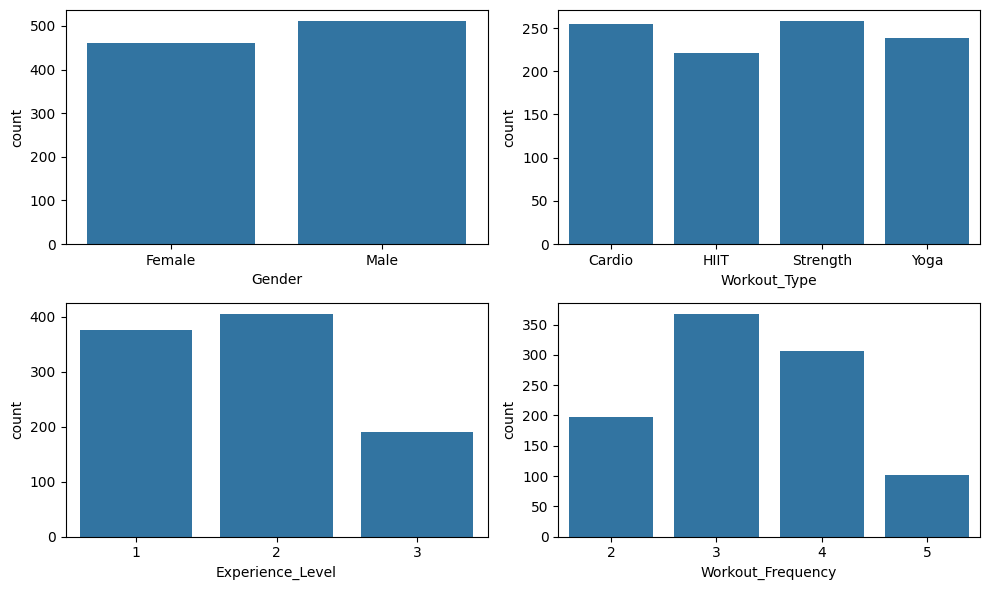

In [32]:
import seaborn as sns
fig = plt.subplots(2,2,figsize=(10,6))
plt.subplot(2,2,1)
sns.barplot(gym["Gender"].value_counts())

plt.subplot(2,2,2)
sns.barplot(gym["Workout_Type"].value_counts())

plt.subplot(2,2,3)
sns.barplot(gym["Experience_Level"].value_counts())

plt.subplot(2,2,4)
sns.barplot(gym["Workout_Frequency"].value_counts())

plt.tight_layout()
plt.show()

**Comments**: 
- We have an balance proportion of men and women in the dataset
- There is no type of workout that is privileged than others
- The number of people with exprerience level 3 is much lower than people with expreience level 1 and 2
- Most of people train for 3 or 4 sessions a week. 


## Quantitative variable

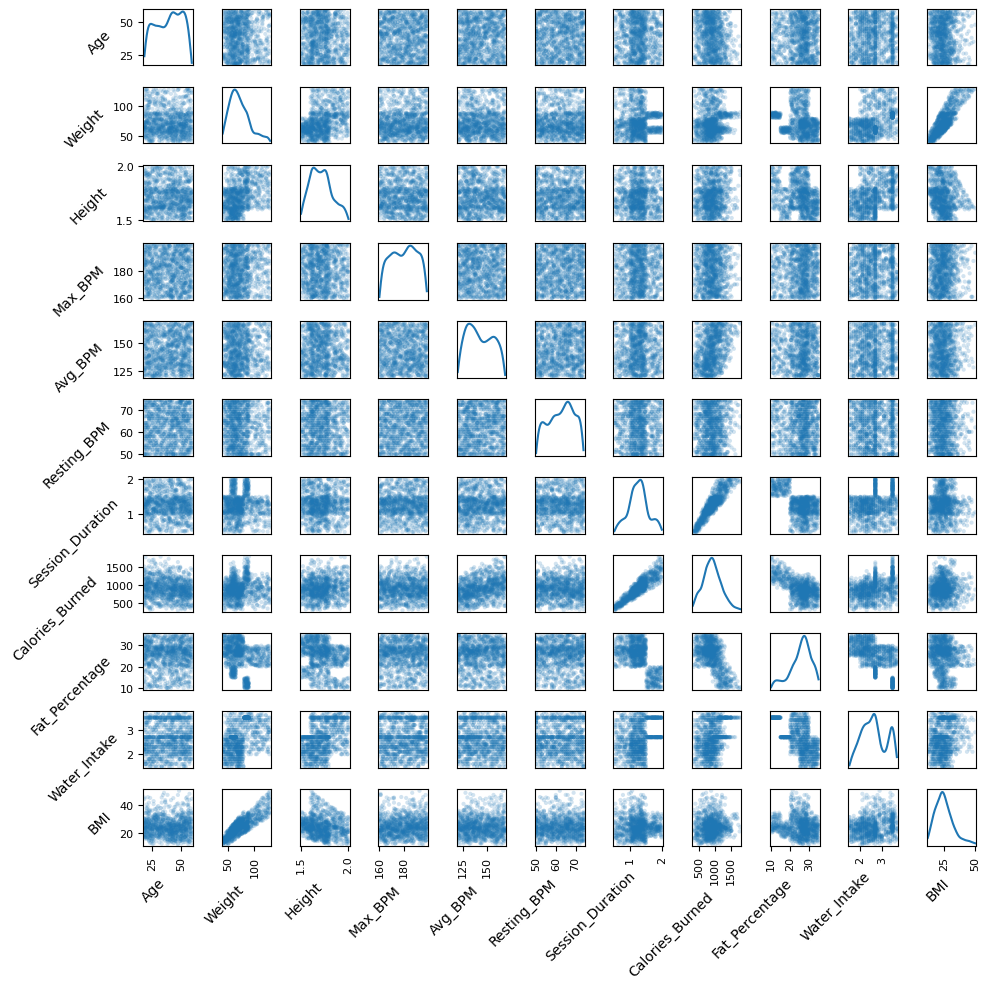

In [33]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'gym' is your DataFrame
from pandas.plotting import scatter_matrix

# Create the scatter matrix
sm = scatter_matrix(gym[['Age', 'Weight', 'Height', 'Max_BPM', 'Avg_BPM','Resting_BPM',
               'Session_Duration', 'Calories_Burned','Fat_Percentage', 'Water_Intake', 'BMI']],
              alpha=0.2,
              diagonal='kde',
              figsize=(10,10))

# Get the current figure
fig = plt.gcf()

# Loop through all axes in the figure
for ax in fig.axes:
    # Rotate the variable names on the diagonal plots
    if ax.get_title():
        ax.set_title(ax.get_title(), rotation=45, ha='right')

    # Rotate the variable names on the off-diagonal plots
    if ax.get_xlabel():
        ax.set_xlabel(ax.get_xlabel(), rotation=45, ha='right')
    if ax.get_ylabel():
        ax.set_ylabel(ax.get_ylabel(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

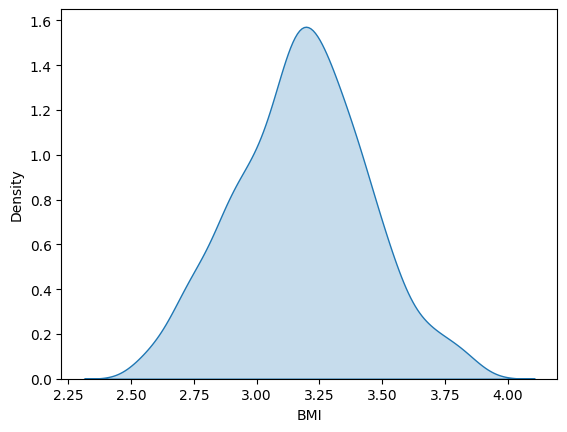

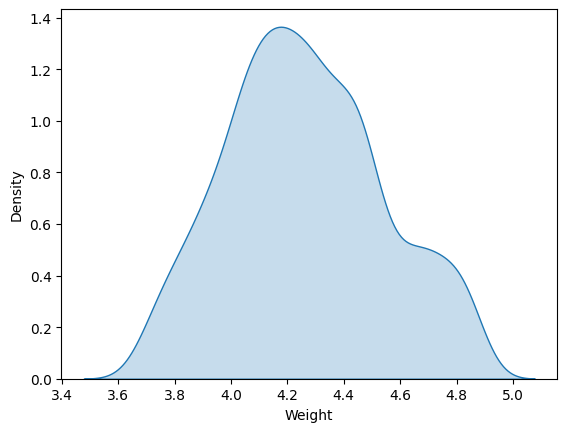

In [34]:
# Data transformation
var = 'BMI'
sns.kdeplot(np.log(gym[var]),label='var',fill=True)
plt.show()
gym['LBMI'] = np.log(gym['BMI'])
del gym['BMI']

var = 'Weight'
sns.kdeplot(np.log(gym[var]),label='var',fill=True)
plt.show()
gym['LWeight'] = np.log(gym['Weight'])
del gym['Weight']

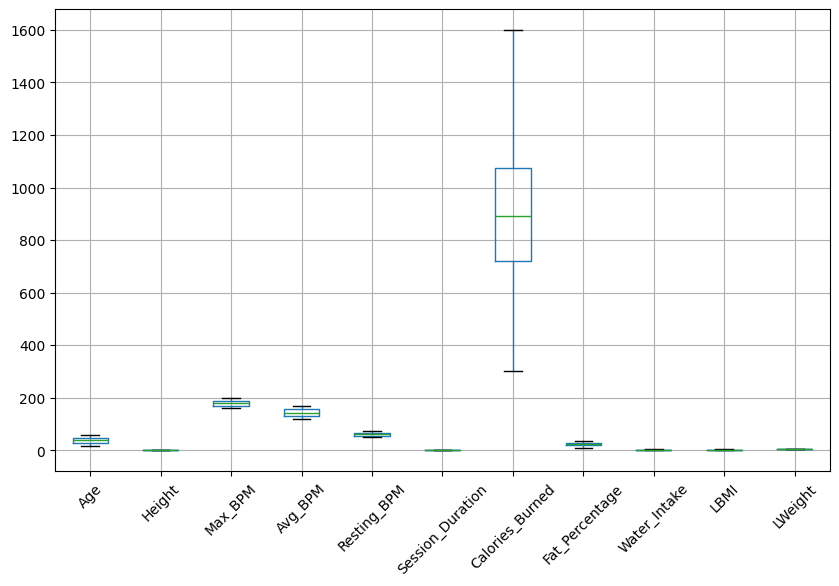

In [35]:
quanti = ['Age', 'Height', 'Max_BPM', 'Avg_BPM', 'Resting_BPM',
       'Session_Duration', 'Calories_Burned', 'Fat_Percentage',
       'Water_Intake', 'LBMI', 'LWeight']
gym[quanti].boxplot(figsize=(10,6), showfliers=False)
plt.xticks(rotation=45)  # Rotate the x-axis labels by 45 degrees
plt.show()

**Comment:** The variables are distrubuted from different scale. We suggest to proceed normalization before doing machine learning.

## Multi-dimensionnal Analyse

### Quanti vs Quanti

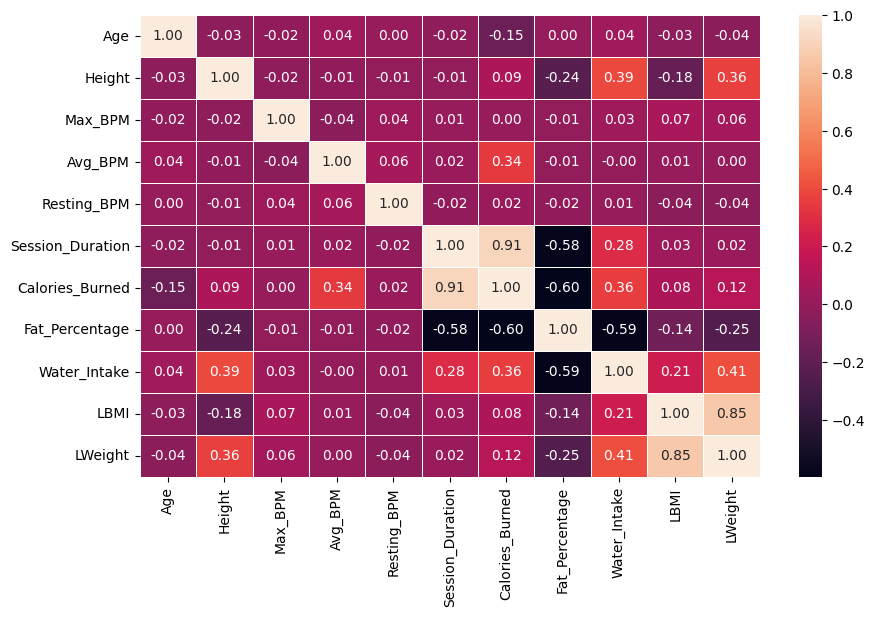

In [36]:
corr = gym[quanti].corr()

plt.figure(figsize = (10,6))
sns.heatmap(corr, annot = True, fmt='.2f',linewidths=0.5)
plt.show()

**Remark**: The two variables Session_Duration and Calories_Burned are strongly correlated, we can remove one of two variables, and keep the other.

### Quali vs Quali

In this section, we check the dependencies between categorical columns.

<Figure size 1000x600 with 0 Axes>

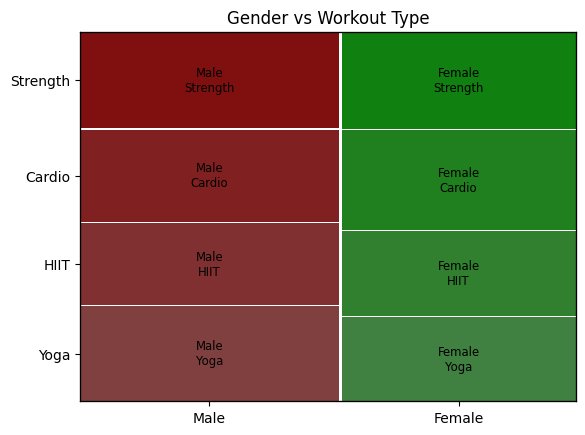

In [37]:
from statsmodels.graphics.mosaicplot import mosaic
gender_workoutType = pd.crosstab(gym['Gender'],gym['Workout_Type'])

fig = plt.figure(figsize=(10,6))
mosaic(gym,['Gender','Workout_Type'],title='Gender vs Workout Type')
plt.show()


**Remark**: The type of workout does not seem to depend on gender.

<Figure size 1000x600 with 0 Axes>

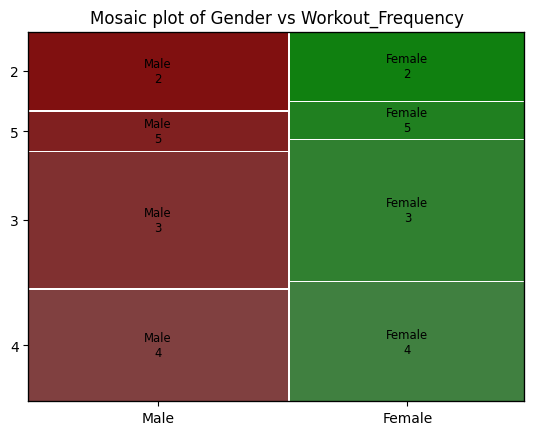

In [38]:
gender_workoutType = pd.crosstab(gym['Gender'],gym['Workout_Frequency'])

fig = plt.figure(figsize=(10,6))
mosaic(gym,['Gender','Workout_Frequency'],title='Mosaic plot of Gender vs Workout_Frequency')
plt.show()


**Remark**: The workout frequency does not seem to depend on gender.

<Figure size 1000x600 with 0 Axes>

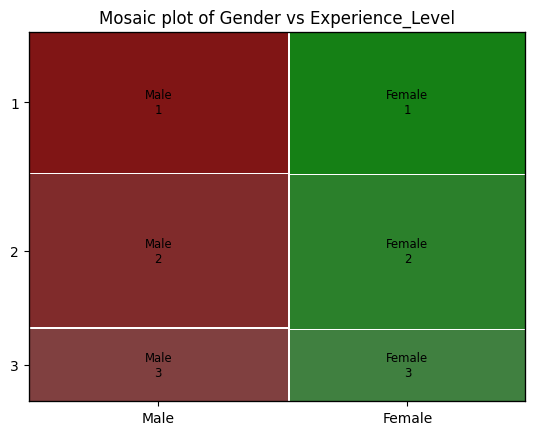

In [39]:
gender_workoutType = pd.crosstab(gym['Gender'],gym['Experience_Level'])

fig = plt.figure(figsize=(10,6))
mosaic(gym,['Gender','Experience_Level'],title='Mosaic plot of Gender vs Experience_Level')
plt.show()

**Remark**: The experience level does not seem to depend on gender.

<Figure size 1000x600 with 0 Axes>

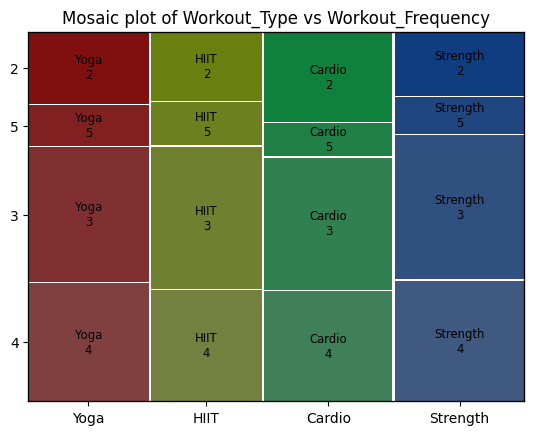

In [40]:
gender_workoutType = pd.crosstab(gym['Workout_Type'],gym['Workout_Frequency'])

fig = plt.figure(figsize=(10,6))
mosaic(gym,['Workout_Type','Workout_Frequency'],title='Mosaic plot of Workout_Type vs Workout_Frequency')
plt.show()

**Remark**: The workout type does not seem to depend on workout frequency.

<Figure size 1000x600 with 0 Axes>

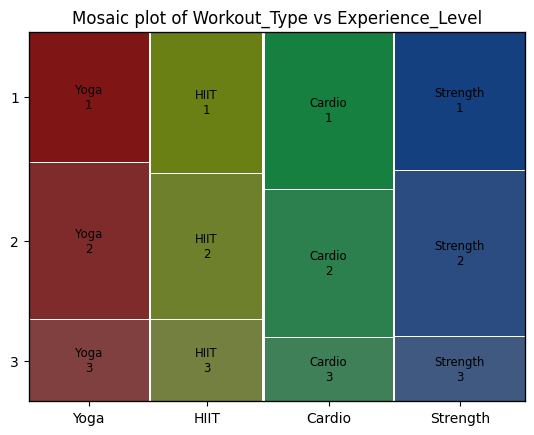

In [41]:
gender_workoutType = pd.crosstab(gym['Workout_Type'],gym['Experience_Level'])

fig = plt.figure(figsize=(10,6))
mosaic(gym,['Workout_Type','Experience_Level'],title='Mosaic plot of Workout_Type vs Experience_Level')
plt.show()

**Remark**: The workout type does not seem to depend on workout frequency.

<Figure size 1000x600 with 0 Axes>

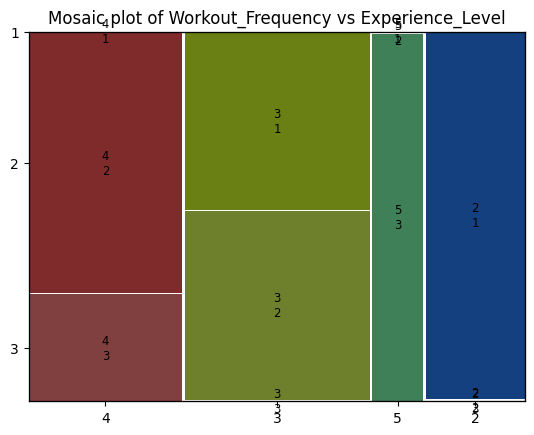

In [42]:
gender_workoutType = pd.crosstab(gym['Experience_Level'],gym['Workout_Frequency'])

fig = plt.figure(figsize=(10,6))
mosaic(gym,['Workout_Frequency','Experience_Level'],title='Mosaic plot of Workout_Frequency vs Experience_Level')
plt.show()

**Remark**: The contingency table is bi-diagonal, we can say that a person with more experience goes to the gym more often.

### Quanti vs Quali

Boxplot of all quantitative variables according to Gender


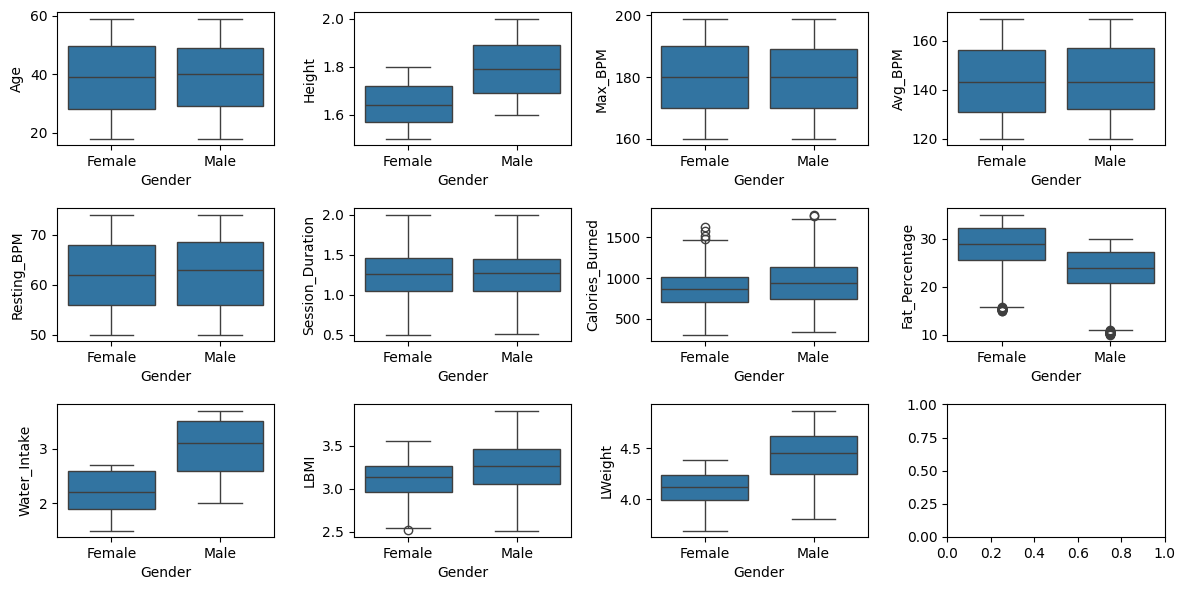

-----------------------------------------------------------------------------------
Boxplot of all quantitative variables according to Workout_Type


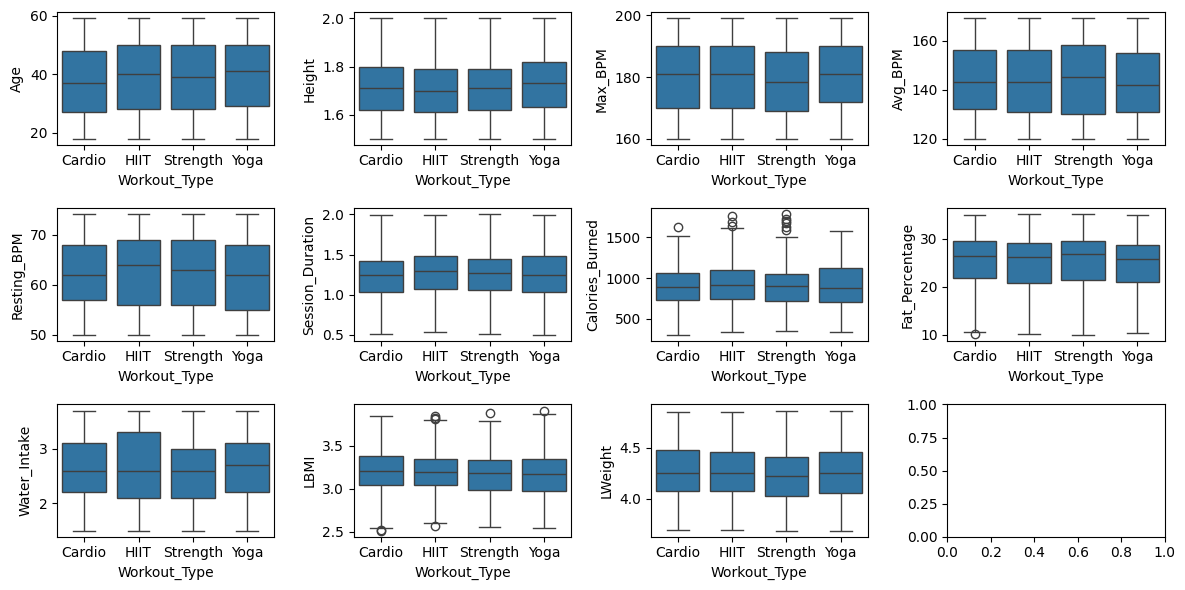

-----------------------------------------------------------------------------------
Boxplot of all quantitative variables according to Workout_Frequency


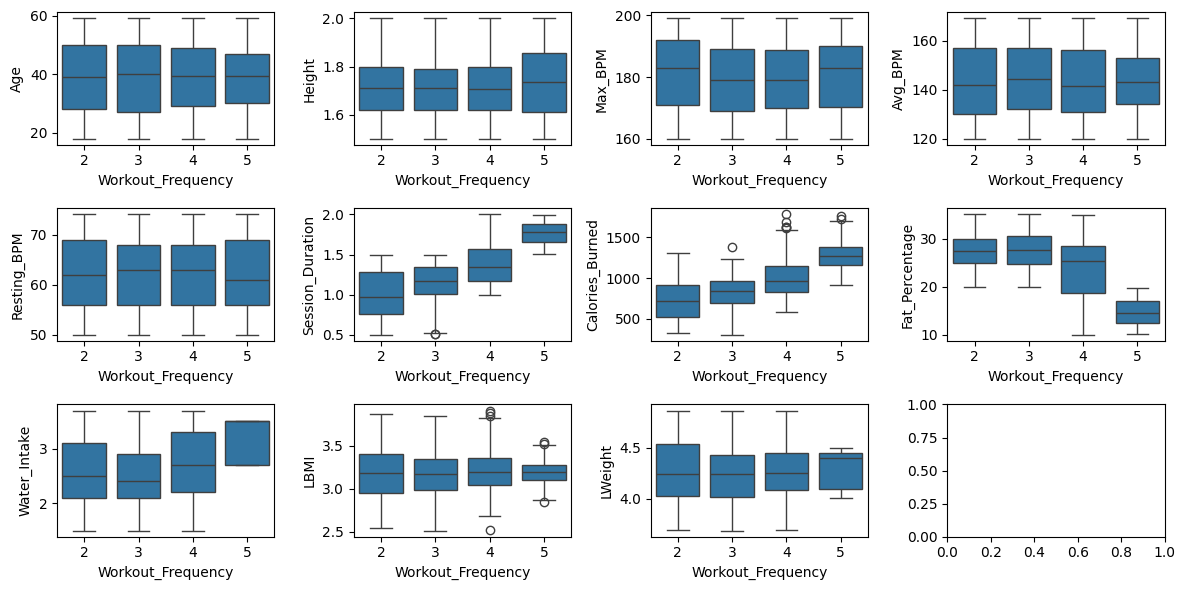

-----------------------------------------------------------------------------------
Boxplot of all quantitative variables according to Experience_Level


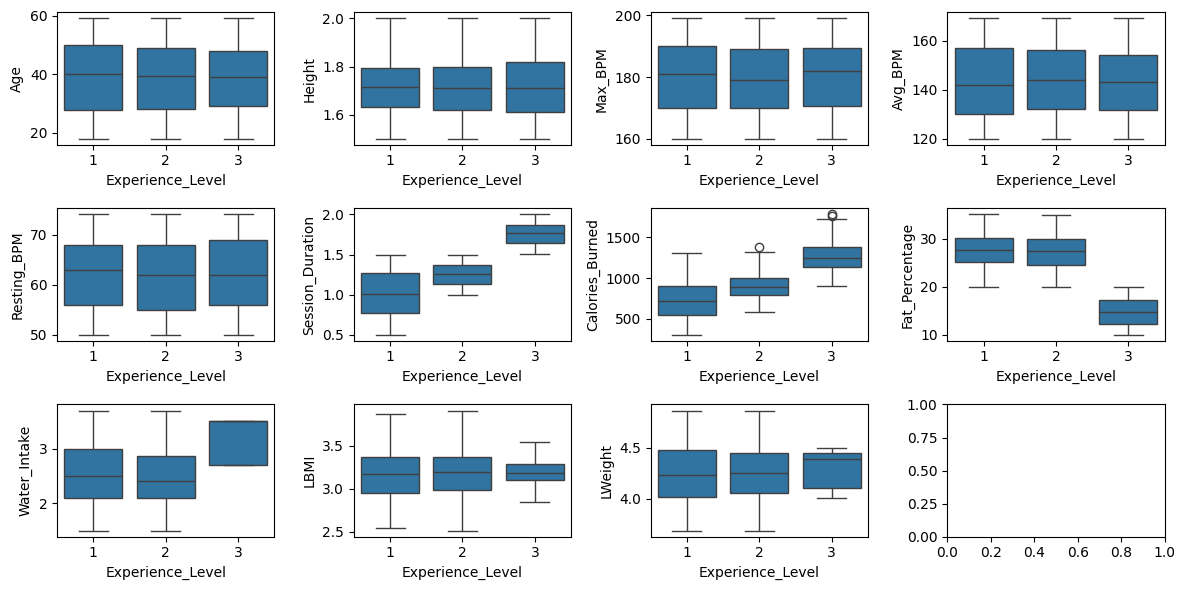

-----------------------------------------------------------------------------------


In [43]:
quali = ['Gender','Workout_Type','Workout_Frequency','Experience_Level']

for i in range(len(quali)):
    print(f"Boxplot of all quantitative variables according to {quali[i]}")
    fig, axes = plt.subplots(3,4,figsize=(12,6))
    axes = np.ravel(axes)
    for j in range(len(quanti)):
        sns.boxplot(x=quali[i],y=quanti[j],data=gym,showfliers=True,ax=axes[j])
#         axes[j].set_title(f"{quanti[j]} vs {quali[i]}")
        # axes[j].axis('off')
    plt.tight_layout()
    plt.show()
    print ("-----------------------------------------------------------------------------------")

**Remark: on average**,
- Men are higher than women in the physical index, such as height, Weight, BMI
- Men consume more water and burn mor calories than women.
- A person who goes to gym more frequently and/or has more experience, has a longer session, burns more calories, and has a lower fat percentage.

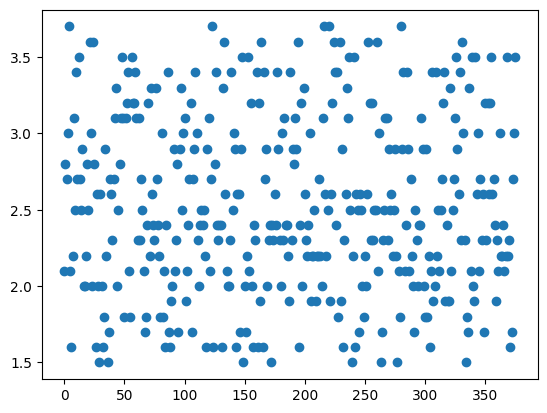

In [44]:
temp = gym['Water_Intake'][gym['Experience_Level']==1]
t = np.arange(len(temp))
plt.scatter(t,temp)

**Remark**: Somehow, the Water_Intake like a categorical variable.

In [45]:
gym['Water_Intake'] = gym['Water_Intake'].astype('category')

In [46]:
gym['Water_Intake'].unique()

[3.5, 2.1, 2.3, 2.8, 2.7, ..., 3.6, 2.4, 1.5, 1.7, 3.2]
Length: 23
Categories (23, float64): [1.5, 1.6, 1.7, 1.8, ..., 3.4, 3.5, 3.6, 3.7]

**Remark:** There are 23 distingish values which make it dificult to treat 'Water_Intake' variable as categorical variables, therefore, we consider 'Water_Intake' as discret quantitative variable.

In [47]:
gym['Water_Intake'] = gym['Water_Intake'].astype('float64')

# Principal component Analyse (PCA)

In [48]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale

X = scale(gym[quanti])

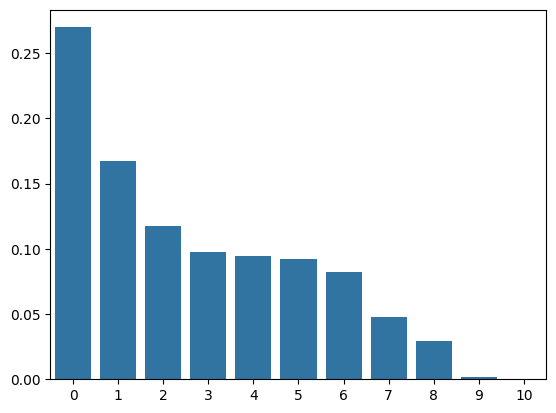

In [49]:
pca = PCA()
X_pca = pca.fit(X).transform(X)
sns.barplot(pca.explained_variance_ratio_)
plt.show()

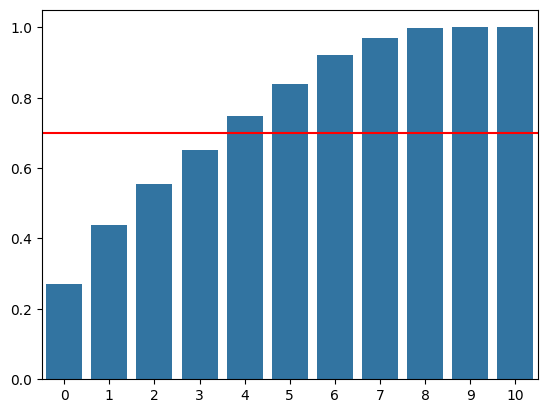

In [50]:
sns.barplot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(y=0.7,color='r',linestyle='-')
plt.show()

**Remark**: The first four axes occupy more than 70% of the total variation, we can therefore keep only these 4 axes as mesures of interpretation.

### Representation of individuals

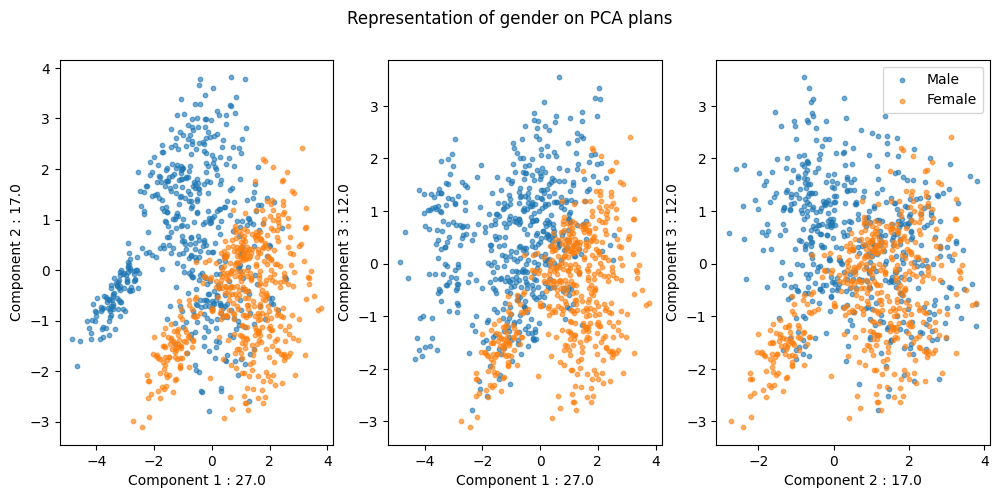

In [51]:
fig,axs = plt.subplots(1,3,figsize=(12,5))
pt_size=10

male_idx = gym['Gender'] =='Male'
axs[0].scatter(X_pca[male_idx,0],X_pca[male_idx,1],alpha=0.6, s=pt_size,label='Male')
axs[0].scatter(X_pca[~male_idx,0],X_pca[~male_idx,1],alpha=0.6, s=pt_size,label='Female')
axs[0].set_xlabel(f"Component 1 : {np.round(pca.explained_variance_ratio_[0]*100.0)}")
axs[0].set_ylabel(f"Component 2 : {np.round(pca.explained_variance_ratio_[1]*100.0)}")

axs[1].scatter(X_pca[male_idx,0],X_pca[male_idx,2],alpha=0.6, s=pt_size,label='Male')
axs[1].scatter(X_pca[~male_idx,0],X_pca[~male_idx,1],alpha=0.6, s=pt_size,label='Female')
axs[1].set_xlabel(f"Component 1 : {np.round(pca.explained_variance_ratio_[0]*100.0)}")
axs[1].set_ylabel(f"Component 3 : {np.round(pca.explained_variance_ratio_[2]*100.0)}")

axs[2].scatter(X_pca[male_idx,1],X_pca[male_idx,2],alpha=0.6, s=pt_size,label='Male')
axs[2].scatter(X_pca[~male_idx,0],X_pca[~male_idx,1],alpha=0.6, s=pt_size,label='Female')
axs[2].set_xlabel(f"Component 2 : {np.round(pca.explained_variance_ratio_[1]*100.0)}")
axs[2].set_ylabel(f"Component 3 : {np.round(pca.explained_variance_ratio_[2]*100.0)}")

plt.legend()
plt.suptitle('Representation of gender on PCA plans')
plt.show()

**Comment:** In PCA plans, the male individuals situate in the top left, while the female individuals situate in the bottom right. However, the existence of a plan that can well separate males and female individuals is not evident.

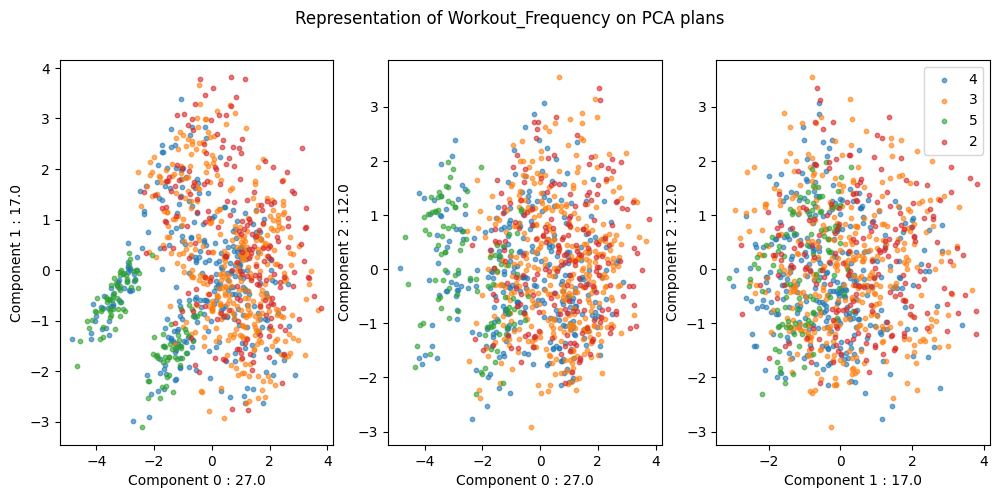

In [52]:
fig,axs = plt.subplots(1,3,figsize=(12,5))
cmps =np.array([[0,1],[0,2],[1,2]])
for i,ax in enumerate(axs.flat):
    for freq in gym['Workout_Frequency'].unique():
        idx = gym['Workout_Frequency']==freq
        ax.scatter(X_pca[idx,cmps[i,0]],X_pca[idx,cmps[i,1]],alpha=0.6, s=pt_size,label=freq)
    ax.set_xlabel(f"Component {cmps[i,0]} : {np.round(pca.explained_variance_ratio_[cmps[i,0]]*100.0)}")
    ax.set_ylabel(f"Component {cmps[i,1]} : {np.round(pca.explained_variance_ratio_[cmps[i,1]]*100.0)}")
plt.legend()
plt.suptitle('Representation of Workout_Frequency on PCA plans')
plt.show()

**Comment:** People who go to gym 5 times a week seem to stand out from the rest.

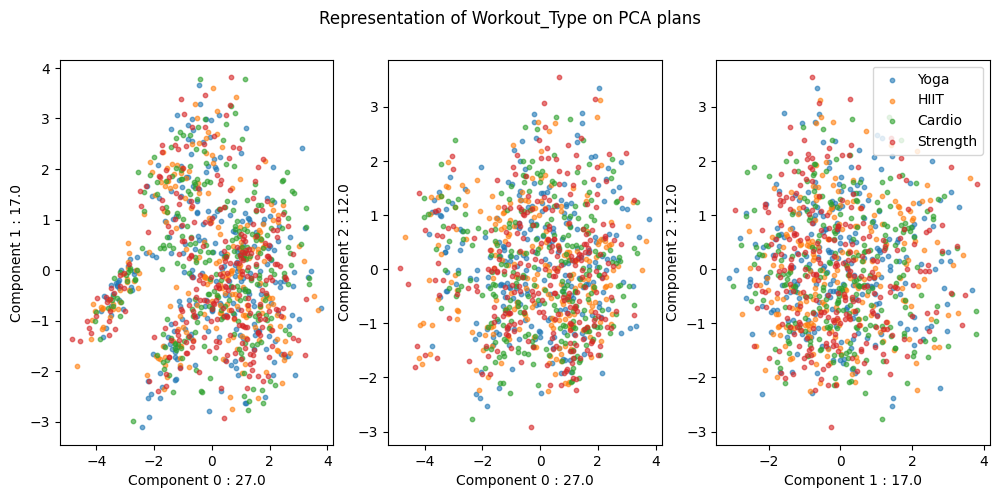

In [53]:
fig,axs = plt.subplots(1,3,figsize=(12,5))
cmps =np.array([[0,1],[0,2],[1,2]])
for i,ax in enumerate(axs.flat):
    for type in gym['Workout_Type'].unique():
        idx = gym['Workout_Type']==type
        ax.scatter(X_pca[idx,cmps[i,0]],X_pca[idx,cmps[i,1]],alpha=0.6, s=pt_size,label=type)
    ax.set_xlabel(f"Component {cmps[i,0]} : {np.round(pca.explained_variance_ratio_[cmps[i,0]]*100.0)}")
    ax.set_ylabel(f"Component {cmps[i,1]} : {np.round(pca.explained_variance_ratio_[cmps[i,1]]*100.0)}")
plt.legend()
plt.suptitle('Representation of Workout_Type on PCA plans')
plt.show()

**Comment**: There is no visible separation for the workout types in pca plans, this observation suggests that all workout types have the same effect on people practicing them and there is no distinction in the profile of people for each workout type.

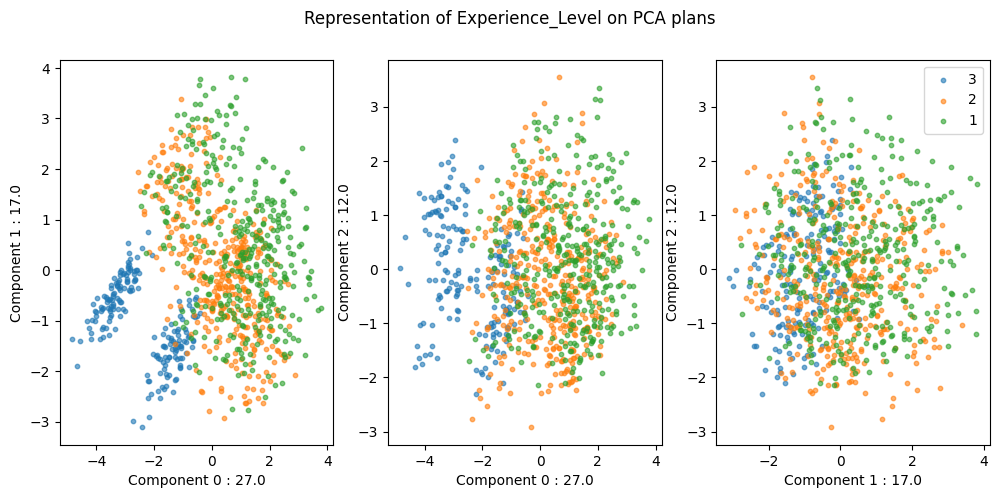

In [54]:
fig,axs = plt.subplots(1,3,figsize=(12,5))
cmps =np.array([[0,1],[0,2],[1,2]])
for i,ax in enumerate(axs.flat):
    for exp in gym['Experience_Level'].unique():
        idx = gym['Experience_Level']==exp
        ax.scatter(X_pca[idx,cmps[i,0]],X_pca[idx,cmps[i,1]],alpha=0.6, s=pt_size,label=exp)
    ax.set_xlabel(f"Component {cmps[i,0]} : {np.round(pca.explained_variance_ratio_[cmps[i,0]]*100.0)}")
    ax.set_ylabel(f"Component {cmps[i,1]} : {np.round(pca.explained_variance_ratio_[cmps[i,1]]*100.0)}")
plt.legend()
plt.suptitle('Representation of Experience_Level on PCA plans')
plt.show()

**Comment**:  People of experience level 3 stand out from the rest.

### Representation of quantitative variables

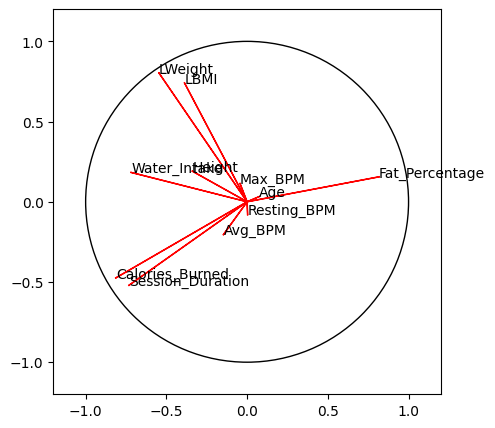

In [55]:
coord0 = pca.components_[0]*np.sqrt(pca.explained_variance_[0])
coord1 = pca.components_[1]*np.sqrt(pca.explained_variance_[1])
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1, 1, 1)
for i,j,nom in zip(coord0,coord1,quanti):
    plt.text(i,j,nom)
    plt.arrow(0,0,i,j,color='red')
plt.axis((-1.2,1.2,-1.2,1.2))
c=plt.Circle((0,0),radius=1.0,color='black',fill=False)
ax.add_patch(c)
plt.show()

**Remark**: 
- We have 2 strongly correlated couples of variables; they are ('Lweight','LBMI') and ('Calories_Burned','Session_Duration').
- The angle formed by (LWeight, LBMI) and Calories_burned is closed to 90 degres, suggesting that calories_burned is independent from these variables. We can consider removing these two variables while performing predictive models on calories_burned.
- Fat_percentages is negatively correlated to calories_burned and session_duration, which is coherent with what we have observed while performing descriptive analysis.

# Calories Burned Prediction

## Training and test data splitting

In [56]:
gym_CBpred = gym.drop(['LBMI','LWeight'],axis=1)

In [57]:
quanti.remove('LBMI')
quanti.remove('LWeight')

In [58]:
gymDum = pd.get_dummies(gym_CBpred,quali,dtype=int)
del gymDum['Gender_Female']
gymDum.head()

,Age,Height,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration,Calories_Burned,Fat_Percentage,Water_Intake,Gender_Male,...,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga,Workout_Frequency_2,Workout_Frequency_3,Workout_Frequency_4,Workout_Frequency_5,Experience_Level_1,Experience_Level_2,Experience_Level_3
0,56,1.71,180,157,60,1.69,1313.0,12.6,3.5,1,...,0,0,1,0,0,1,0,0,0,1
1,46,1.53,179,151,66,1.30,883.0,33.9,2.1,0,...,1,0,0,0,0,1,0,0,1,0
2,32,1.66,167,122,54,1.11,677.0,33.4,2.3,0,...,0,0,0,0,0,1,0,0,1,0
3,25,1.70,190,164,56,0.59,532.0,28.8,2.1,1,...,0,1,0,0,1,0,0,1,0,0
4,38,1.79,188,158,68,0.64,556.0,29.2,2.8,1,...,0,1,0,0,1,0,0,1,0,0


In [59]:
from sklearn.model_selection import train_test_split
X = gymDum.drop(columns=['Calories_Burned'])
y = gymDum['Calories_Burned']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

print("Mean of X_train:", np.mean(X_train, axis=0))  # Should be close to 0
print("Variance of X_train:", np.var(X_train, axis=0))  # Should be close to 1

print('---------------------------------------------------------------------------')

print("Mean of X_train:", np.mean(X_test, axis=0))  
print("Variance of X_train:", np.var(X_test, axis=0))  

Mean of X_train: [-1.14161751e-16 -1.13933427e-15  6.37022568e-16  3.03670257e-16
  3.94999657e-16  5.41126698e-16 -2.73988201e-17 -4.84045823e-16
 -2.51155851e-17  1.05028811e-16 -4.56647002e-17 -1.09595281e-16
 -4.33814652e-17 -3.53901427e-17  4.56647002e-17  2.28323501e-17
  7.99132254e-18 -7.53467554e-17 -3.88149952e-17 -7.76299904e-17]
Variance of X_train: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
---------------------------------------------------------------------------
Mean of X_train: [ 0.02149282 -0.09860144  0.00869134  0.08530579  0.01260262  0.00699846
 -0.04525993 -0.10981037 -0.06953931 -0.07386357 -0.03490885 -0.0678896
  0.18441081  0.17233754 -0.1542879   0.00931974  0.01171943  0.03490159
 -0.08259218  0.06065624]
Variance of X_train: [1.01743396 0.88966563 0.97736897 0.95314065 0.91732623 1.18344727
 1.01622327 0.97096611 1.00412102 0.91743545 0.95400541 0.92551621
 1.20252783 1.24417447 0.90880326 1.00740063 1.03024548 1.01557718
 0.96827109 1.0

## Linear Model

### Without Regularization

In [61]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

reg = LinearRegression()
reg.fit(X_train,y_train)
prev_reg = reg.predict(X_test)
mse_linear = mean_squared_error(y_test,prev_reg)
r2_linear = r2_score(y_test,prev_reg)
print("MSE by Linear Regression model is :",mse_linear)
print("R2=",r2_linear)

MSE by Linear Regression model is : 1674.6080538960093
R2= 0.9799267900605536


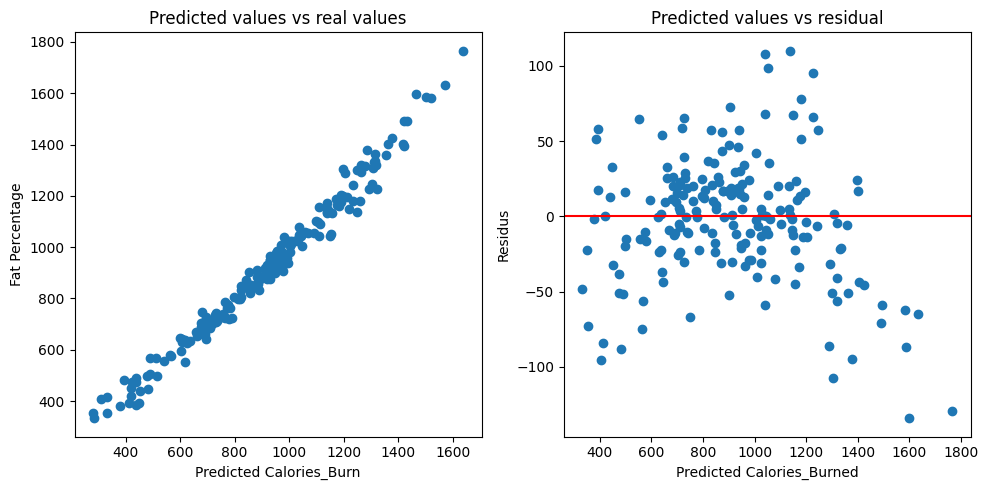

In [62]:

fig,axs = plt.subplots(1,2,figsize=(10,5))
axs[0].scatter(prev_reg,y_test)
axs[0].set_xlabel('Predicted Calories_Burn')
axs[0].set_ylabel('Fat Percentage')
axs[0].set_title('Predicted values vs real values')

axs[1].scatter(y_test,prev_reg - y_test)
axs[1].axhline(y=0.0,color='r',linestyle='-')
axs[1].set_xlabel('Predicted Calories_Burned')
axs[1].set_ylabel('Residus')
axs[1].set_title('Predicted values vs residual')

plt.tight_layout()
plt.show()

**Comment**: The result is really good, the linear model performed reasonably well on the test set. The predicted values are quite close to the real values as the cloud of points situate on the diagonal of the graph. However, the residuals semble not independent (banana form), and the plot suggest that the residuals depend on predicted values, these observations do not meet the gaussian assumption of regression model.

In [63]:
def coeff_display(coeff,title="Coeffs plot"):
    coeff_series = pd.Series(coeff, index = X.columns)

    coeff_series.plot(kind='barh', color='skyblue', edgecolor='black')
    # Adding labels and title
    plt.xlabel('Values')
    plt.ylabel('Categories')
    plt.title(title)
    
    # Display the plot
    plt.tight_layout()
    plt.show()

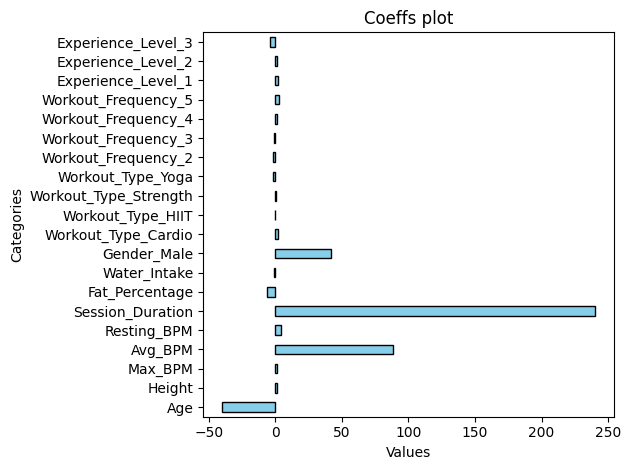

In [64]:

coeff_lin_noReg = pd.Series(reg.coef_, index = X.columns)
coeff_display(coeff_lin_noReg)


**Comment:**
- Basing on the absolute values of coefficients, The variable Session_Duration, Avg_BPM, Gender, Age, Fat_percentage and Resting_BMP columns are significant to the predicted values of calories burned.
- The experience level, workout frequency have very low impact in the predicted values of calories burned although the multi-dimensional analysis above suggests that there are strong correlations between experience level, workout frequency and calories burned. Possible reason for this counter-intuitive observation is that the information of experience level, workout frequency may be included in others variables such as session duration, Avg_BPM.
- On the other hand, age is weakly correlated with calories burned but its coefficient is significative, in sense of absolute value, this observation need to be explain.

In [65]:
# Create a table of stock the performance of models

performance = pd.DataFrame(columns=['Model name','MSE','R2'])
performance.loc[len(performance)] = {'Model name':'Linear Regression','MSE':mse_linear,'R2':r2_linear}
print(performance)


          Model name          MSE        R2
0  Linear Regression  1674.608054  0.979927


### With Regularization

#### Lasso

In [66]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
# param=[{"alpha":[0.05,0.1,0.2,0.3,0.4,0.5,1,1.2,1.4,1.6,1.8,2.0]}]
# regLasso = GridSearchCV(Lasso(),param,cv=10,n_jobs=-1)
# regLassOpt=regLasso.fit(X_train, y_train)
# # Optimal parameters
# regLassOpt.best_params_["alpha"]
# print("Meilleur R2 = %f, Meilleur paramètre = %s" % (regLassOpt.best_score_,regLassOpt.best_params_))

MSE by Lasso model on test set is : 1642.663646700602
R2= 0.9803097016263571


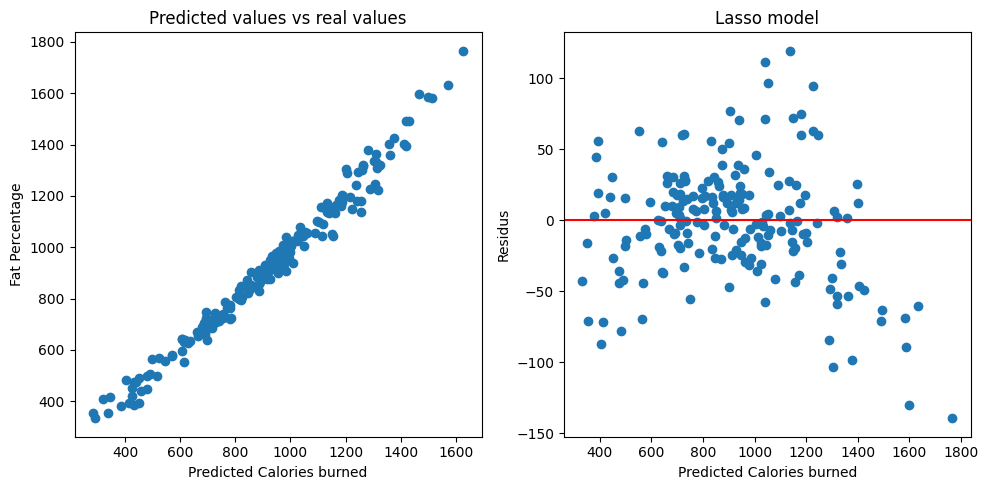

In [67]:
regLasso=Lasso(alpha=1.2)    # 1.2 is optimal alpha found using the GridSearchCV code commented above
model_lasso=regLasso.fit(X_train,y_train)
prev_lasso = model_lasso.predict(X_test)

mse_lasso = mean_squared_error(y_test,prev_lasso)
r2_lasso = r2_score(y_test,prev_lasso)
print("MSE by Lasso model on test set is :",mse_lasso)
print("R2=",r2_lasso)

fig,axs = plt.subplots(1,2,figsize=(10,5))
axs[0].scatter(prev_lasso,y_test)
axs[0].set_xlabel('Predicted Calories burned')
axs[0].set_ylabel('Fat Percentage')
axs[0].set_title('Predicted values vs real values')

axs[1].scatter(y_test,prev_lasso - y_test)
axs[1].axhline(y=0.0,color='r',linestyle='-')
axs[1].set_xlabel('Predicted Calories burned')
axs[1].set_ylabel('Residus')
axs[1].set_title('Predicted values vs residuals')

plt.title('Lasso model')
plt.tight_layout()
plt.show()



**Comment**: Basing on the mean squared erros and R2 score, the lasso model performs slightly better than linear model without regularization. However, the bad behavior on the residuals still persists.

In [68]:
performance.loc[len(performance)] = {'Model name':'Lasso','MSE':mse_lasso,'R2':r2_lasso}
print(performance)

          Model name          MSE        R2
0  Linear Regression  1674.608054  0.979927
1              Lasso  1642.663647  0.980310


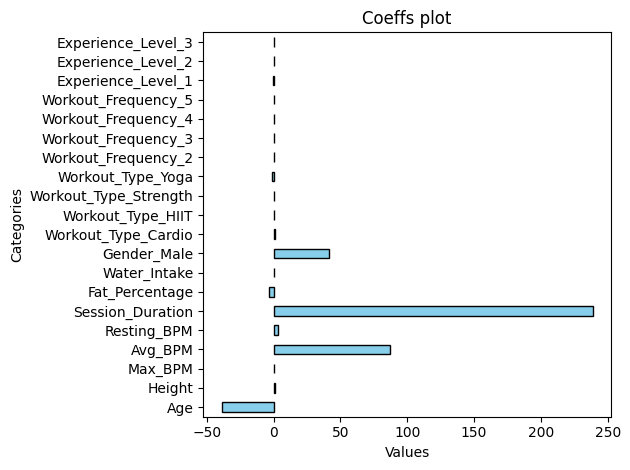

In [69]:

coeff_display(model_lasso.coef_)

**Comment:**
- The same significant variables in L1 penalization model as in the non-penalization model.
- Under l1 penalization, the coefficients are nearly zero, except for a few significant variables.

#### L2 Regularization

In [70]:
from sklearn.linear_model import Ridge


# param=[{"alpha":np.arange(0,5.2,0.2)+0.05}]
# regRidge = GridSearchCV(Ridge(),param,cv=10,n_jobs=-1)
# regRidgeOpt=regRidge.fit(X_train, y_train)
# # Optimal parameters
# regRidgeOpt.best_params_["alpha"]
# print("Meilleur R2 = %f, Meilleur paramètre = %s" % (regRidgeOpt.best_score_,regRidgeOpt.best_params_))

MSE by Ridge model is : 1676.1953153776244
R2 score :  0.9799077638574518


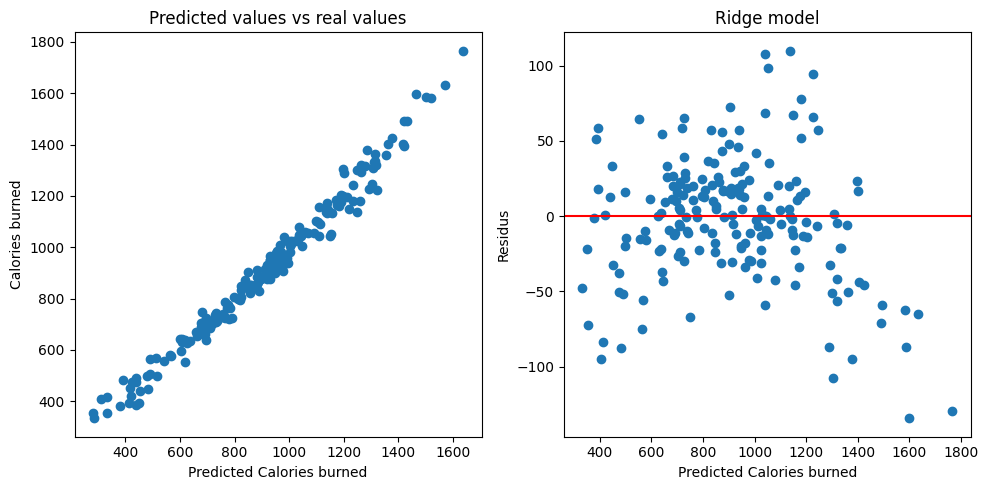

In [71]:
regRidge=Ridge(alpha=0.45)
model_ridge=regRidge.fit(X_train,y_train)
# print(model_ridge.coef_)

prev_ridge = model_ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test,prev_ridge)
r2_ridge =  r2_score(y_test,prev_ridge)

print("MSE by Ridge model is :",mse_ridge)
print("R2 score : ",r2_ridge)

fig,axs = plt.subplots(1,2,figsize=(10,5))
axs[0].scatter(prev_ridge,y_test)
axs[0].set_xlabel('Predicted Calories burned')
axs[0].set_ylabel('Calories burned')
axs[0].set_title('Predicted values vs real values')

axs[1].scatter(y_test,prev_ridge - y_test)
axs[1].axhline(y=0.0,color='r',linestyle='-')
axs[1].set_xlabel('Predicted Calories burned')
axs[1].set_ylabel('Residus')
axs[1].set_title('Predicted values vs residuals')

plt.title('Ridge model')
plt.tight_layout()
plt.show()

**Comment**: The result visually is the same as lasso and linear model. 

In [72]:
performance.loc[len(performance)] = {'Model name':'Ridge','MSE':mse_ridge,'R2':r2_ridge}
print(performance)


          Model name          MSE        R2
0  Linear Regression  1674.608054  0.979927
1              Lasso  1642.663647  0.980310
2              Ridge  1676.195315  0.979908


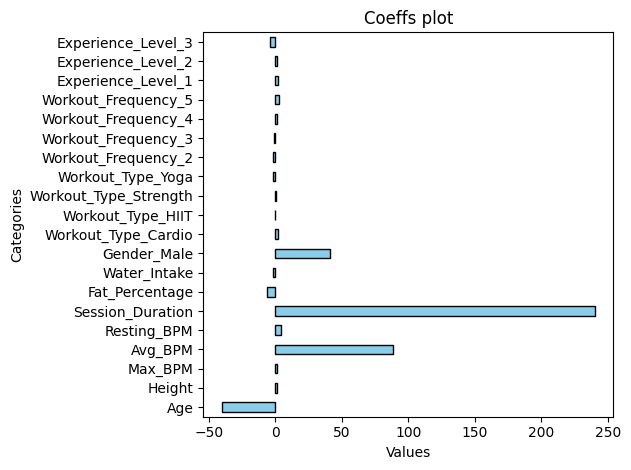

In [73]:
coef = coeff_display(model_ridge.coef_)


**Comment**: The values of coefficients are almost similar to these in non-penalization model.

## Support Vector Regression

### Linear Kernel

In [74]:
from sklearn.svm import SVR

# param={"C":np.linspace(459,461,10),
#        "epsilon":np.linspace(2.0,2.2,10),
#        "kernel":['linear']}
# svr_model = GridSearchCV(SVR(),param,cv=10,n_jobs=-1)
# svrOpt=svr_model.fit(X_train, y_train)
# # Optimal parameters
# svrOpt.best_params_["C"]
# svrOpt.best_params_["kernel"]
# print("Meilleur R2 = %f, Meilleur paramètre = %s" % (svrOpt.best_score_,svrOpt.best_params_))


MSE with linear kernel : 1752.9423265448954
R2 score :  0.978987811953601


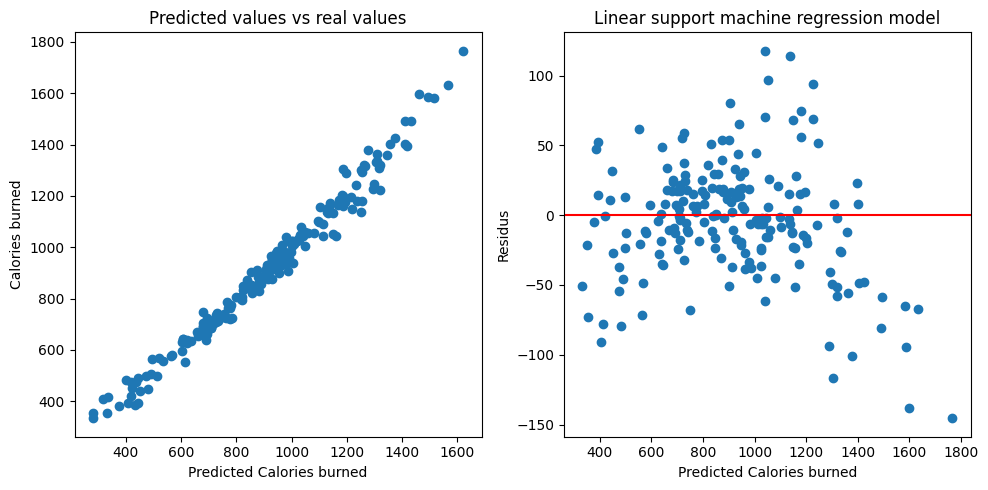

In [75]:
svr=SVR(C=461.0,epsilon = 2.1333333,kernel='linear')
svr_model=svr.fit(X_train,y_train)


prev_svr = svr_model.predict(X_test)
mse_svr = mean_squared_error(y_test,prev_svr)
r2_svr =  r2_score(y_test,prev_svr)

print("MSE with linear kernel :",mse_svr)
print("R2 score : ",r2_svr)

fig,axs = plt.subplots(1,2,figsize=(10,5))
axs[0].scatter(prev_svr,y_test)
axs[0].set_xlabel('Predicted Calories burned')
axs[0].set_ylabel('Calories burned')
axs[0].set_title('Predicted values vs real values')

axs[1].scatter(y_test,prev_svr - y_test)
axs[1].axhline(y=0.0,color='r',linestyle='-')
axs[1].set_xlabel('Predicted Calories burned')
axs[1].set_ylabel('Residus')
axs[1].set_title('Predicted values vs residuals')

plt.title('Linear support machine regression model')
plt.tight_layout()
plt.show()

In [76]:
performance.loc[len(performance)] = {'Model name':'linear SVR','MSE':mse_svr,'R2':r2_svr}
print(performance)

          Model name          MSE        R2
0  Linear Regression  1674.608054  0.979927
1              Lasso  1642.663647  0.980310
2              Ridge  1676.195315  0.979908
3         linear SVR  1752.942327  0.978988


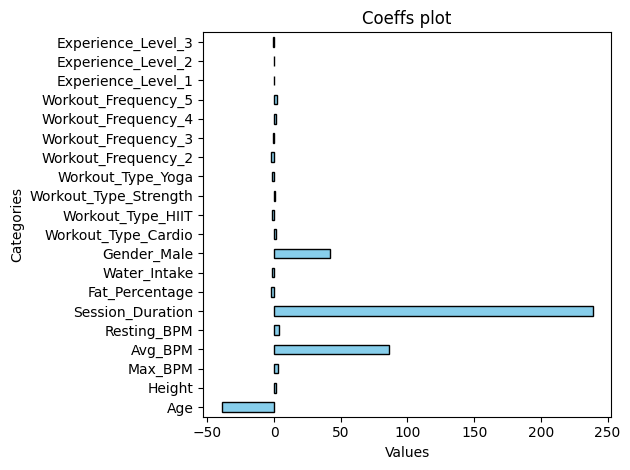

In [77]:
coeff_display(svr_model.coef_[0,:])


### Polynomial Kernel

In [78]:
# param={"C":np.arange(400,500,20),
#       "epsilon":np.arange(10,50,5),
#       "degree": [1,2,3,4]}
# svr_model = GridSearchCV(SVR(kernel='poly'),param,cv=10,n_jobs=-1)
# svrOpt=svr_model.fit(X_train, y_train)
# # Optimal parameters
# svrOpt.best_params_["C"]
# svrOpt.best_params_["kernel"]
# svrOpt.best_params_["degree"]
# print("Meilleur R2 = %f, Meilleur paramètre = %s" % (svrOpt.best_score_,svrOpt.best_params_))

MSE with polinomial kernel : 1752.9423265448954
R2 score :  0.978987811953601


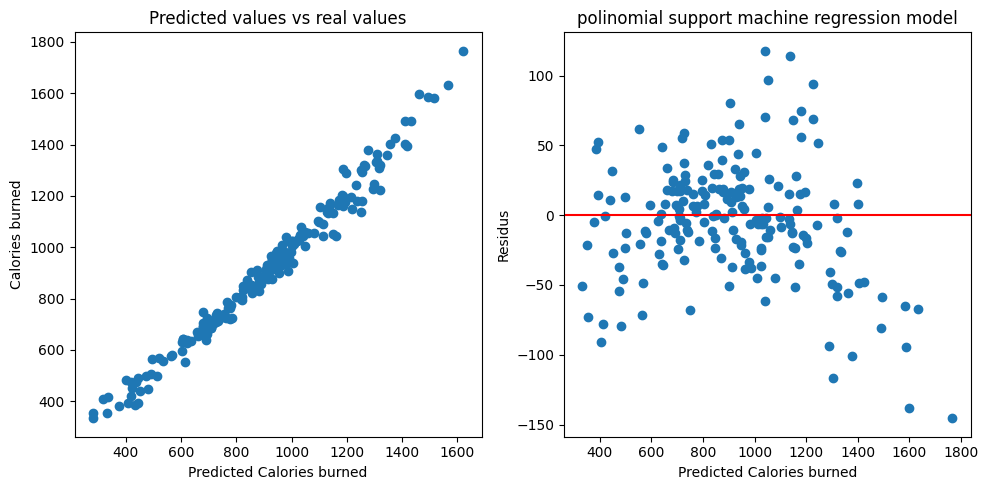

In [79]:
poly_svr=SVR(C=460.0,epsilon = 40.0,kernel='poly',degree=1)
poly_svr_model=svr.fit(X_train,y_train)

prev_svr = poly_svr_model.predict(X_test)
mse_svr = mean_squared_error(y_test,prev_svr)
r2_svr =  r2_score(y_test,prev_svr)

print("MSE with polinomial kernel :",mse_svr)
print("R2 score : ",r2_svr)

fig,axs = plt.subplots(1,2,figsize=(10,5))
axs[0].scatter(prev_svr,y_test)
axs[0].set_xlabel('Predicted Calories burned')
axs[0].set_ylabel('Calories burned')
axs[0].set_title('Predicted values vs real values')

axs[1].scatter(y_test,prev_svr - y_test)
axs[1].axhline(y=0.0,color='r',linestyle='-')
axs[1].set_xlabel('Predicted Calories burned')
axs[1].set_ylabel('Residus')
axs[1].set_title('Predicted values vs residuals')

plt.title('polinomial support machine regression model')
plt.tight_layout()
plt.show()

In [80]:
performance.loc[len(performance)] = {'Model name':'polinomial SVR','MSE':mse_svr,'R2':r2_svr}
print(performance)

          Model name          MSE        R2
0  Linear Regression  1674.608054  0.979927
1              Lasso  1642.663647  0.980310
2              Ridge  1676.195315  0.979908
3         linear SVR  1752.942327  0.978988
4     polinomial SVR  1752.942327  0.978988


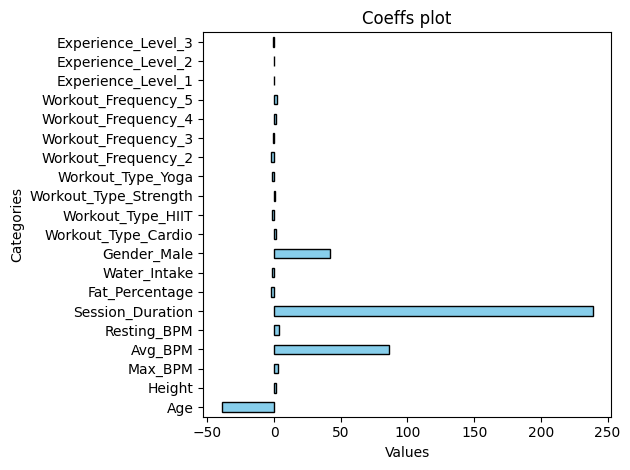

In [81]:
coeff = pd.Series(poly_svr_model.coef_[0], index = X.columns)

coeff_display(coeff)

### Radial Kerel

In [82]:
# param= {
#     'C': [0.1, 1, 10, 100, 1000,10000],
#     'gamma': [0.0001, 0.001, 0.01, 0.1, 1],
#     'epsilon': [0.01, 0.1, 0.2, 0.5, 1]
# }
# svr_model = GridSearchCV(SVR(kernel='rbf'),param,cv=10,n_jobs=-1)
# svrOpt=svr_model.fit(X_train, y_train)
# # Optimal parameters
# svrOpt.best_params_["C"]
# svrOpt.best_params_["gamma"]
# svrOpt.best_params_["epsilon"]
# print("Meilleur R2 = %f, Meilleur paramètre = %s" % (svrOpt.best_score_,svrOpt.best_params_))

MSE with polinomial kernel : 769.6862870784557
R2 score :  0.9907739160861588


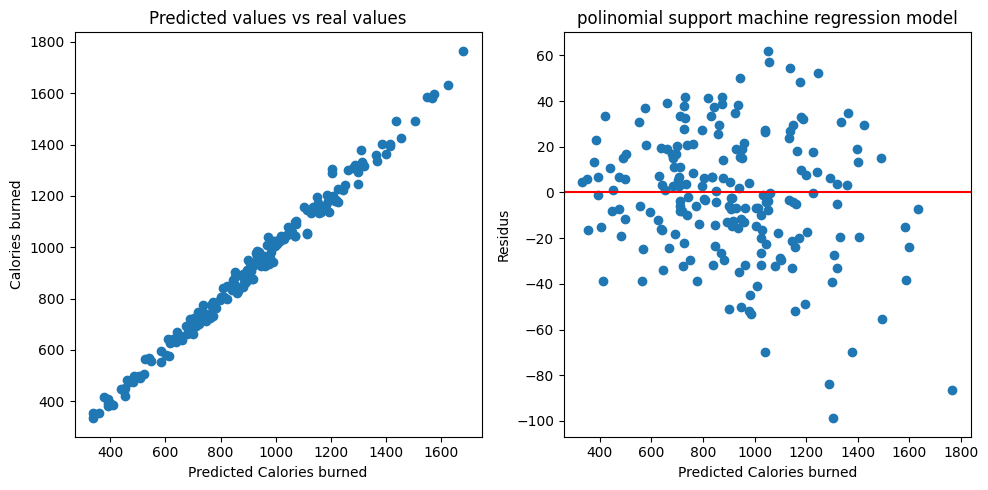

In [83]:
radial_svr=SVR(C=1000.0,epsilon = 0.01,gamma=0.01,kernel='rbf')
radial_svr_model=radial_svr.fit(X_train,y_train)

prev_svr = radial_svr.predict(X_test)
mse_svr = mean_squared_error(y_test,prev_svr)
r2_svr =  r2_score(y_test,prev_svr)

print("MSE with polinomial kernel :",mse_svr)
print("R2 score : ",r2_svr)

fig,axs = plt.subplots(1,2,figsize=(10,5))
axs[0].scatter(prev_svr,y_test)
axs[0].set_xlabel('Predicted Calories burned')
axs[0].set_ylabel('Calories burned')
axs[0].set_title('Predicted values vs real values')

axs[1].scatter(y_test,prev_svr - y_test)
axs[1].axhline(y=0.0,color='r',linestyle='-')
axs[1].set_xlabel('Predicted Calories burned')
axs[1].set_ylabel('Residus')
axs[1].set_title('Predicted values vs residuals')

plt.title('polinomial support machine regression model')
plt.tight_layout()
plt.show()

In [84]:
performance.loc[len(performance)] = {'Model name':'radial SVR','MSE':mse_svr,'R2':r2_svr}
print(performance)

          Model name          MSE        R2
0  Linear Regression  1674.608054  0.979927
1              Lasso  1642.663647  0.980310
2              Ridge  1676.195315  0.979908
3         linear SVR  1752.942327  0.978988
4     polinomial SVR  1752.942327  0.978988
5         radial SVR   769.686287  0.990774


In [85]:
# import shap

# # Use SHAP to explain the model's predictions
# explainer = shap.KernelExplainer(radial_svr.predict, X_train)
# shap_values = explainer.shap_values(X_test)

# # Plot the SHAP summary plot
# shap.summary_plot(shap_values, X_test, feature_names=X.columns)

## Random Forest

In [86]:
from sklearn.ensemble import RandomForestRegressor

# param= {
#     "max_features":list(range(5,15,2)),
#     "max_depth": [None, 10, 20, 30],    # Maximum depth of each tree
#     "min_samples_split": [2, 5, 10],    # Minimum samples required to split an internal node
#     "min_samples_leaf": [1, 2, 4]
# }
# rf= GridSearchCV(RandomForestRegressor(n_estimators=500),
#         param,cv=5,n_jobs=-1)
# rfOpt=rf.fit(X_train, y_train)
# # paramètre optimal
# print("Meilleur score = %f, Meilleur paramètre = %s" % (rfOpt.best_score_,rfOpt.best_params_))

In [87]:
rf= RandomForestRegressor(n_estimators=500,
                          max_features=13,
                         max_depth=20,
                         min_samples_split=2,
                         min_samples_leaf=1)
rfFit=rf.fit(X_train, y_train)


MSE by random forest model on test set is : 2333.132320615385
R2= 0.9720331842551089


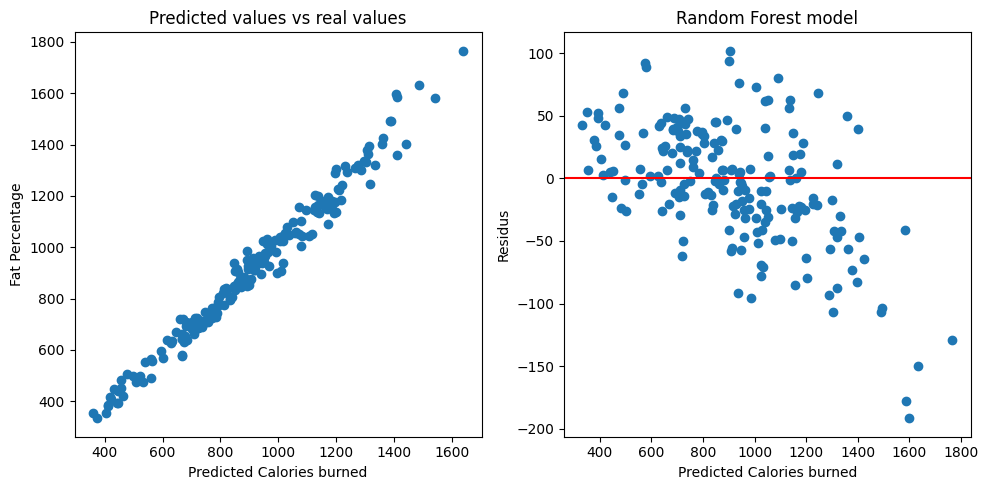

In [88]:
prev_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test,prev_rf)
r2_rf = r2_score(y_test,prev_rf)
print("MSE by random forest model on test set is :",mse_rf)
print("R2=",r2_rf)

fig,axs = plt.subplots(1,2,figsize=(10,5))
axs[0].scatter(prev_rf,y_test)
axs[0].set_xlabel('Predicted Calories burned')
axs[0].set_ylabel('Fat Percentage')
axs[0].set_title('Predicted values vs real values')

axs[1].scatter(y_test,prev_rf - y_test)
axs[1].axhline(y=0.0,color='r',linestyle='-')
axs[1].set_xlabel('Predicted Calories burned')
axs[1].set_ylabel('Residus')
axs[1].set_title('Predicted values vs residuals')

plt.title('Random Forest model')
plt.tight_layout()
plt.show()



**Comment**: The random forest does not perform as well as the other model as the high MSE and the residuals does not visually follow the normal law.

Session_Duration 0.6493211363722534
Avg_BPM 0.09851539895960518
Fat_Percentage 0.08482954227817655
Experience_Level_3 0.07858582157143909
Age 0.02167481853995934
Experience_Level_1 0.017455036652486298
Gender_Male 0.00997767775732411
Experience_Level_2 0.009628865505952933
Height 0.007537449384076009
Water_Intake 0.006659331640228236
Resting_BPM 0.005014341067147395
Max_BPM 0.004196304607477171
Workout_Frequency_5 0.002043315347611483
Workout_Type_Strength 0.0009051301949059765
Workout_Type_Cardio 0.0008419360089014203
Workout_Type_Yoga 0.0006666992242598754
Workout_Type_HIIT 0.0006340178874160094
Workout_Frequency_4 0.0006031100495668825
Workout_Frequency_2 0.0004835720207455561
Workout_Frequency_3 0.0004264949304671163


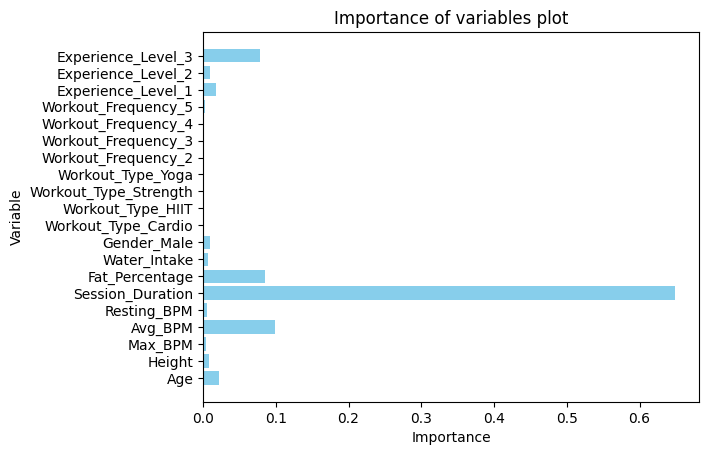

In [89]:
# Variables' importance 
importances = rfFit.feature_importances_
indices = np.argsort(importances)[::-1]
for f in range(X_train.shape[1]):
    print(X.columns[indices[f]], importances[indices[f]])


# Create a horizontal bar plot
plt.barh(X.columns, importances, color='skyblue')

# Labels and title
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.title("Importance of variables plot")

# Show the plot
plt.show()

In [90]:
performance.loc[len(performance)] = {'Model name':'Random Forest','MSE':mse_rf,'R2':r2_rf}
print(performance)

          Model name          MSE        R2
0  Linear Regression  1674.608054  0.979927
1              Lasso  1642.663647  0.980310
2              Ridge  1676.195315  0.979908
3         linear SVR  1752.942327  0.978988
4     polinomial SVR  1752.942327  0.978988
5         radial SVR   769.686287  0.990774
6      Random Forest  2333.132321  0.972033


## Boosting Algorithms

### AdaBoosting Regression

Mean Squared Error: 2509.30
R2 Score : 0.9699214653048279


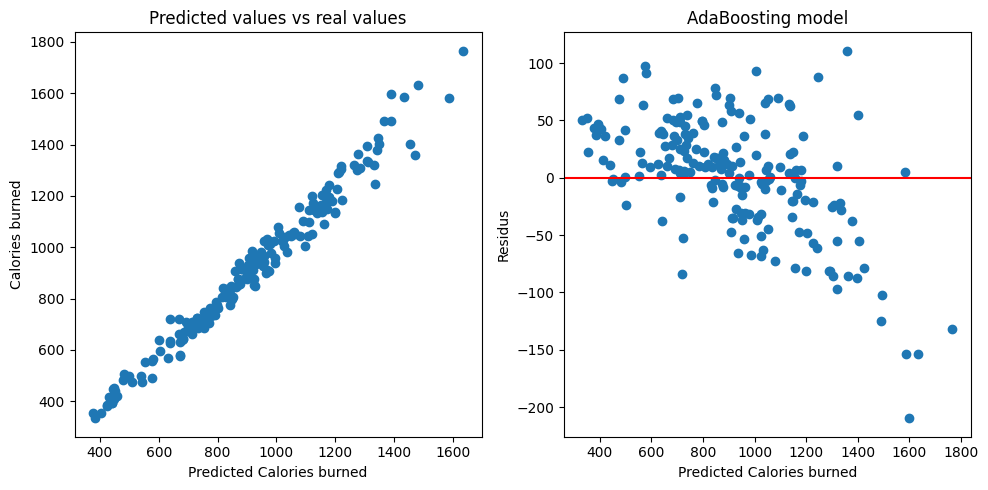

In [91]:
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.datasets import make_regression



# param= {
#     "n_estimators":[100,200,300],
#     "learning_rate": [0.01,0.1,0.5,1,2,5]    # Maximum depth of each tree
# }
# AdaBoostTuner= GridSearchCV(AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=8),random_state=42),
#         param,cv=5,n_jobs=-1)
# AdaBoostOpt=AdaBoostTuner.fit(X_train, y_train)
# # paramètre optimal
# print("Meilleur score = %f, Meilleur paramètre = %s" % (AdaBoostOpt.best_score_,AdaBoostOpt.best_params_))

# Define AdaBoost Regressor with Decision Tree as a weak learner
adaboost_regressor = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=5),  # Weak learner
    n_estimators=300,  # Number of weak learners
    learning_rate=1,  # Step size
    random_state=42
)

# Train the model
adaboost_regressor.fit(X_train, y_train)

# Make predictions
y_pred = adaboost_regressor.predict(X_test)

# 🔹 Evaluate performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print("R2 Score :",r2)

fig,axs = plt.subplots(1,2,figsize=(10,5))
axs[0].scatter(y_pred,y_test)
axs[0].set_xlabel('Predicted Calories burned')
axs[0].set_ylabel('Calories burned')
axs[0].set_title('Predicted values vs real values')

axs[1].scatter(y_test,y_pred - y_test)
axs[1].axhline(y=0.0,color='r',linestyle='-')
axs[1].set_xlabel('Predicted Calories burned')
axs[1].set_ylabel('Residus')
axs[1].set_title('Predicted values vs residuals')

plt.title('AdaBoosting model')
plt.tight_layout()
plt.show()


The prediction quality is as well as the Random Forest, but the residual plot suggest that the error does not follow the normal distribution.

In [92]:
performance.loc[len(performance)] = {'Model name':'AdaBoosting','MSE':mse,'R2':r2}
print(performance)

          Model name          MSE        R2
0  Linear Regression  1674.608054  0.979927
1              Lasso  1642.663647  0.980310
2              Ridge  1676.195315  0.979908
3         linear SVR  1752.942327  0.978988
4     polinomial SVR  1752.942327  0.978988
5         radial SVR   769.686287  0.990774
6      Random Forest  2333.132321  0.972033
7        AdaBoosting  2509.302528  0.969921


In [93]:
from sklearn.metrics import mean_absolute_percentage_error
mape = mean_absolute_percentage_error
print("MAPE : ", mape(y_test,y_pred)*100)

MAPE :  4.395600616249945


### Gradient Boosting Regression

In [94]:
from sklearn.ensemble import GradientBoostingRegressor


# Define parameter grid for tuning
param_grid = {
    'n_estimators': [50, 100, 200],        # Number of trees
    'learning_rate': [0.01, 0.1, 0.5,1],     # Shrinkage factor
    'max_depth': [3, 4, 5],                # Tree depth
    'subsample': [0.8, 1.0]                # Fraction of samples per tree
}

# 🔹 Step 5: Perform GridSearchCV
gbrTuner = GridSearchCV(GradientBoostingRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,                                  # 5-fold cross-validation
    scoring='neg_mean_absolute_error',     # Use MAE (or change to MAPE)
    n_jobs=-1,                             # Use all CPU cores
    verbose=1
)

gbrTuner.fit(X_train, y_train)

# Print the best hyperparameters
print("Best Parameters:", gbrTuner.best_params_)

# Evaluate the best model on test data
gbr_model = gbrTuner.best_estimator_
y_pred = gbr_model.predict(X_test)

# Calculate Mean Absolute Percentage Error (MAPE)
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"MAPE on Test Data: {mape:.2f}")


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
MAPE on Test Data: 0.01


In [95]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print("R2 Score :",r2)

Mean Squared Error: 301.80
R2 Score : 0.996382418202438


In [96]:
performance.loc[len(performance)] = {'Model name':'GRadientBoosting','MSE':mse,'R2':r2}
print(performance)

          Model name          MSE        R2
0  Linear Regression  1674.608054  0.979927
1              Lasso  1642.663647  0.980310
2              Ridge  1676.195315  0.979908
3         linear SVR  1752.942327  0.978988
4     polinomial SVR  1752.942327  0.978988
5         radial SVR   769.686287  0.990774
6      Random Forest  2333.132321  0.972033
7        AdaBoosting  2509.302528  0.969921
8   GRadientBoosting   301.796854  0.996382


## Neural Network

In [97]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense,Dropout,BatchNormalization
from tensorflow.keras.optimizers import SGD, Adam, Nadam
from tensorflow.keras.callbacks import  EarlyStopping,LearningRateScheduler




In [129]:
X.shape

(973, 20)

In [130]:
Xr_train,Xr_temp,yr_train,yr_temp = train_test_split(X,y,test_size=0.2,random_state=42)
Xr_val,Xr_test,yr_val,yr_test = train_test_split(Xr_temp,yr_temp,test_size=0.5,random_state=42)

In [147]:

def lr_schedule(epoch, lr):
    if epoch < 10:
        return lr  # Keep the learning rate constant for the first 10 epochs
    else:
        return lr * 0.9  # Decay by 10% after 10 epochs

lr_scheduler = LearningRateScheduler(lr_schedule)

keras_model = Sequential()
keras_model.add(Input(shape=(X_train.shape[1],)))
keras_model.add(Dense(128,activation="relu",kernel_initializer='he_normal'))
keras_model.add(BatchNormalization())  
# keras_model.add(Dropout(0.3))
keras_model.add(Dense(64,activation="softplus",kernel_initializer='he_normal'))
keras_model.add(BatchNormalization())  
# keras_model.add(Dropout(0.3))
keras_model.add(Dense(32,activation="softplus",kernel_initializer='he_normal'))
keras_model.add(BatchNormalization())  

keras_model.add(Dense(32,activation="softplus",kernel_initializer='he_normal'))
keras_model.add(BatchNormalization())  
# keras_model.add(Dropout(0.3))
# keras_model.add(Dense(5,activation="relu"))
keras_model.add(Dense(1))


keras_model.compile(optimizer=Nadam(learning_rate=0.5),
                   loss="mse",
                   metrics=["mae"])

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,         # number of epochs with no improvement
    mode='min',
    verbose=1,
    restore_best_weights=True  # restores weights from best epoch
)
history = keras_model.fit(Xr_train,yr_train,
                         epochs=200,batch_size=32,
                          callbacks=[early_stop,lr_scheduler],
                         validation_data=(Xr_val,yr_val))

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 582192.8125 - mae: 664.8416 - val_loss: 335382048.0000 - val_mae: 13971.4805 - learning_rate: 0.5000
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 28372.1738 - mae: 137.8194 - val_loss: 1364464640.0000 - val_mae: 36628.7070 - learning_rate: 0.5000
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 15187.4053 - mae: 96.7173 - val_loss: 117371184.0000 - val_mae: 10795.0586 - learning_rate: 0.5000
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 12508.2012 - mae: 88.7548 - val_loss: 1046387.3125 - val_mae: 837.5950 - learning_rate: 0.5000
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9844.8262 - mae: 75.9852 - val_loss: 8375907.0000 - val_mae: 2873.0583 - learning_rate: 0.5000
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 9027.6416 - mae: 77.0993 - val_loss: 3703716.0000 - val_mae: 1904.6598 - learning_rate: 0.5000
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Mean Squared Error: 656.42
R2 Score : 0.9912737037043106


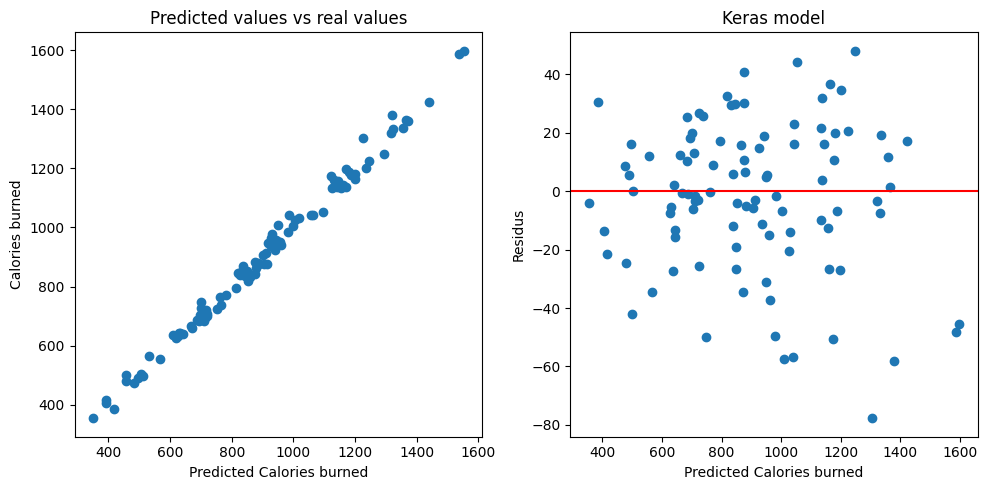

In [149]:
yr_pred = keras_model.predict(Xr_test).ravel()
mse = mean_squared_error(yr_test, yr_pred)
r2 = r2_score(yr_test, yr_pred)

print(f"Mean Squared Error: {mse:.2f}")
print("R2 Score :",r2)

fig,axs = plt.subplots(1,2,figsize=(10,5))
axs[0].scatter(yr_pred,yr_test)
axs[0].set_xlabel('Predicted Calories burned')
axs[0].set_ylabel('Calories burned')
axs[0].set_title('Predicted values vs real values')

axs[1].scatter(yr_test,yr_pred - yr_test)
axs[1].axhline(y=0.0,color='r',linestyle='-')
axs[1].set_xlabel('Predicted Calories burned')
axs[1].set_ylabel('Residus')
axs[1].set_title('Predicted values vs residuals')

plt.title('Keras model')
plt.tight_layout()
plt.show()


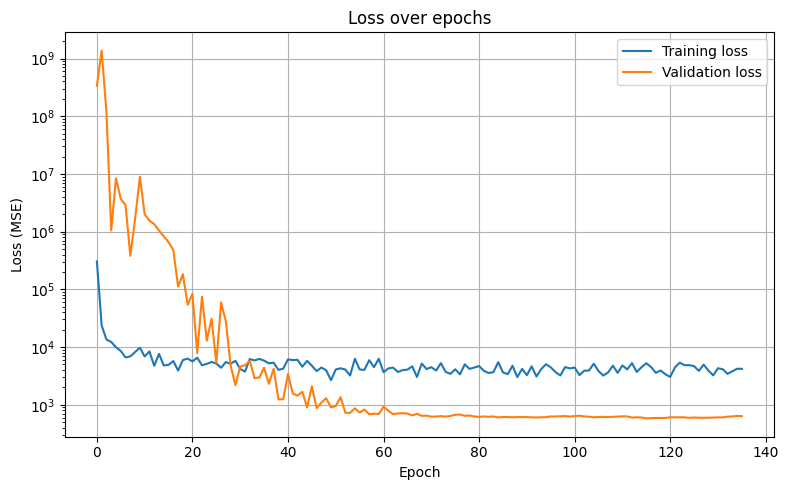

In [150]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.yscale('log')
# plt.ylim([0,10000])
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [101]:
performance.loc[len(performance)] = {'Model name':'NeuralNetwork','MSE':mse,'R2':r2}
print(performance)

          Model name          MSE        R2
0  Linear Regression  1674.608054  0.979927
1              Lasso  1642.663647  0.980310
2              Ridge  1676.195315  0.979908
3         linear SVR  1752.942327  0.978988
4     polinomial SVR  1752.942327  0.978988
5         radial SVR   769.686287  0.990774
6      Random Forest  2333.132321  0.972033
7        AdaBoosting  2509.302528  0.969921
8   GRadientBoosting   301.796854  0.996382
9      NeuralNetwork  1071.250241  0.987159


# Experience Level prediction

## Training and Test data splitting

In [102]:
gym_ELclsf = gym.drop('Experience_Level',axis=1)

In [103]:
quali

['Gender', 'Workout_Type', 'Workout_Frequency', 'Experience_Level']

In [104]:
gymDum_noEL = pd.get_dummies(gym_ELclsf,quali[:-1],dtype=int)
del gymDum_noEL['Gender_Female']
gymDum_noEL.head()

,Age,Height,Max_BPM,Avg_BPM,Resting_BPM,Session_Duration,Calories_Burned,Fat_Percentage,Water_Intake,LBMI,LWeight,Gender_Male,Workout_Type_Cardio,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga,Workout_Frequency_2,Workout_Frequency_3,Workout_Frequency_4,Workout_Frequency_5
0,56,1.71,180,157,60,1.69,1313.0,12.6,3.5,3.407842,4.480740,1,0,0,0,1,0,0,1,0
1,46,1.53,179,151,66,1.30,883.0,33.9,2.1,3.465736,4.316154,0,0,1,0,0,0,0,1,0
2,32,1.66,167,122,54,1.11,677.0,33.4,2.3,3.207208,4.220977,0,1,0,0,0,0,0,1,0
3,25,1.70,190,164,56,0.59,532.0,28.8,2.1,2.912894,3.974058,1,0,0,1,0,0,1,0,0
4,38,1.79,188,158,68,0.64,556.0,29.2,2.8,2.666534,3.830813,1,0,0,1,0,0,1,0,0


In [105]:
Xc_train,Xc_test,yc_train,yc_test = train_test_split(gymDum_noEL,gym['Experience_Level'],test_size=0.2,random_state=42)

## Random Forest

In [106]:
from sklearn.ensemble import RandomForestClassifier 
# définition des paramètres
forest = RandomForestClassifier(n_estimators=500, 
   criterion='gini', max_depth=None,
   min_samples_split=2, min_samples_leaf=1, 
   max_features='sqrt', max_leaf_nodes=None,
   bootstrap=True, oob_score=True)
# apprentissage   
rfFit = forest.fit(Xc_train,yc_train)
print(rfFit.oob_score_)

0.8894601542416453


In [107]:
param= {
    "max_features":[5,8,10,13,16,18,21],
    "max_depth": [None, 10, 20, 30],    # Maximum depth of each tree
    "min_samples_split": [2, 5, 10,20],    # Minimum samples required to split an internal node
    "min_samples_leaf": [1, 2, 4,6]
}
rfcls= GridSearchCV(RandomForestClassifier(n_estimators=500),
        param,cv=5,n_jobs=-1)
rfclsOpt=rfcls.fit(Xc_train, yc_train)
# paramètre optimal
print("Meilleur score = %f, Meilleur paramètre = %s" % (rfclsOpt.best_score_,rfclsOpt.best_params_))

KeyboardInterrupt: 

In [ ]:
rfCls= RandomForestClassifier(n_estimators=500,
                          max_features=rfclsOpt.best_params_['max_features'],
                         max_depth=rfclsOpt.best_params_['max_depth'],
                         min_samples_split=rfclsOpt.best_params_['min_samples_split'],
                         min_samples_leaf=rfclsOpt.best_params_['min_samples_leaf'])
rfClsFit=rfCls.fit(Xc_train, yc_train)

In [ ]:
prev_rfCls = rfClsFit.predict(Xc_test)
print("Rate of accurate prediction: ", np.sum(prev_rfCls==yc_test)/len(yc_test))


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay(confusion_matrix(prev_rfCls, yc_test)).plot()
plt.xlabel('Real Experience Level')
plt.ylabel('Predicted Experience Level')
plt.show()

## Support Vector Machine

Accuracy: 0.90


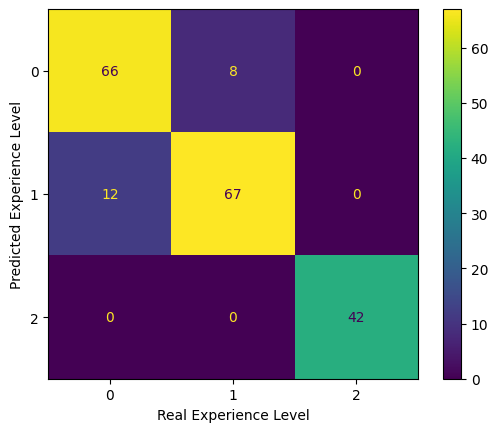

{'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}


In [109]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


svm_model = SVC(kernel="linear", decision_function_shape="ovr") 
svm_model.fit(Xc_train, yc_train)

# Predict on test set
y_pred = svm_model.predict(Xc_test)

# Evaluate accuracy
accuracy = accuracy_score(yc_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

ConfusionMatrixDisplay(confusion_matrix(y_pred, yc_test)).plot()
plt.xlabel('Real Experience Level')
plt.ylabel('Predicted Experience Level')
plt.show()
print(svm_model.get_params())

In [110]:
param_grid = {
    'C': [0.1,0.5, 1.0],                   # Regularization
    'gamma': ['scale', 'auto', 0.1, 1],   # Kernel coefficient
}

# Initialize SVC
svc = SVC(kernel="linear",decision_function_shape='ovr')

# Initialize GridSearchCV
grid_search = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit model
grid_search.fit(Xc_train, yc_train)

# Best parameters and accuracy
print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'C': 0.5, 'gamma': 'scale'}
Best Score: 0.8765591397849463


In [111]:
y_pred = grid_search.predict(Xc_test)

Accuracy: 0.90


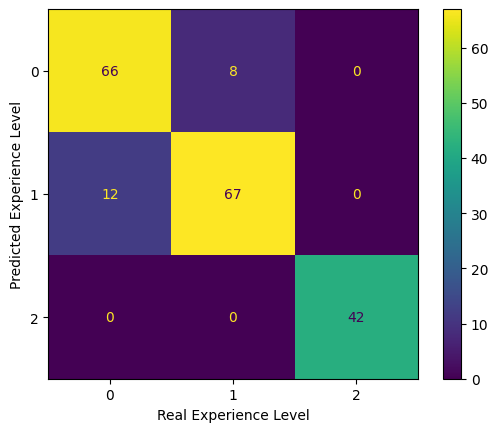

In [112]:
accuracy = accuracy_score(yc_test,y_pred)
print(f"Accuracy: {accuracy:.2f}")

ConfusionMatrixDisplay(confusion_matrix(y_pred, yc_test)).plot()
plt.xlabel('Real Experience Level')
plt.ylabel('Predicted Experience Level')
plt.show()

## Linear Discriminaion Analysis LDA

Accuracy: 0.8564102564102564


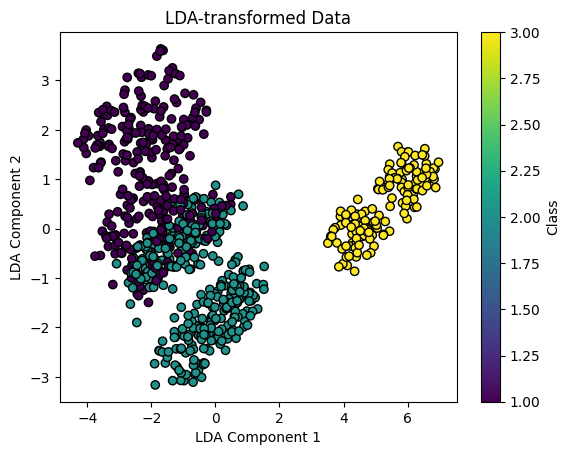

In [113]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis(n_components = 2)

Xc_train_lda = lda.fit_transform(Xc_train,yc_train)
Xc_test_lda = lda.transform(Xc_test)

classifier = RandomForestClassifier(n_estimators=500,random_state=42)
classifier.fit(Xc_train_lda,yc_train)

yc_pred_lda1 = classifier.predict(Xc_test_lda)

accuracy_lda = accuracy_score(yc_test,yc_pred_lda1)
print(f"Accuracy: {accuracy_lda}")


plt.scatter(Xc_train_lda[:, 0], Xc_train_lda[:, 1], c=yc_train, cmap='viridis', edgecolors='k')
plt.title("LDA-transformed Data")
plt.xlabel("LDA Component 1")
plt.ylabel("LDA Component 2")
plt.colorbar(label="Class")
plt.show()


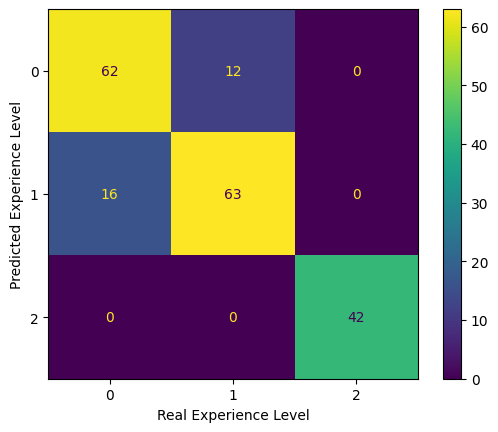

In [114]:
ConfusionMatrixDisplay(confusion_matrix(yc_pred_lda1, yc_test)).plot()
plt.xlabel('Real Experience Level')
plt.ylabel('Predicted Experience Level')
plt.show()

Accuracy: 0.8923076923076924


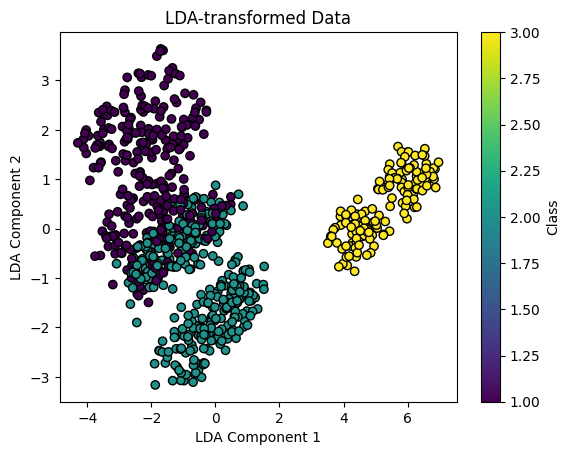

In [115]:
lda = LinearDiscriminantAnalysis(n_components = 2)

Xc_train_lda = lda.fit_transform(Xc_train,yc_train)
Xc_test_lda = lda.transform(Xc_test)

classifier = SVC(kernel='linear',decision_function_shape='ovr')
classifier.fit(Xc_train_lda,yc_train)

yc_pred_lda = classifier.predict(Xc_test_lda)

accuracy_lda = accuracy_score(yc_test,yc_pred_lda)
print(f"Accuracy: {accuracy_lda}")


plt.scatter(Xc_train_lda[:, 0], Xc_train_lda[:, 1], c=yc_train, cmap='viridis', edgecolors='k')
plt.title("LDA-transformed Data")
plt.xlabel("LDA Component 1")
plt.ylabel("LDA Component 2")
plt.colorbar(label="Class")
plt.show()

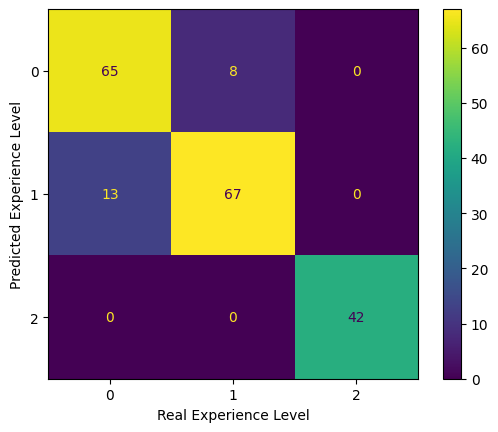

In [116]:
ConfusionMatrixDisplay(confusion_matrix(yc_pred_lda, yc_test)).plot()
plt.xlabel('Real Experience Level')
plt.ylabel('Predicted Experience Level')
plt.show()

## AdaBoosting Classification 

In [117]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier


# Define AdaBoost with a base estimator (Decision Tree)
adaboost_cls = AdaBoostClassifier(estimator=DecisionTreeClassifier())

# Define hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of weak learners
    'learning_rate': [0.01, 0.1, 1],  # Weight of each learner
    'algorithm': ['SAMME', 'SAMME.R']  # Boosting algorithm
}

# Perform Grid Search
grid_search = GridSearchCV(adaboost_cls, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(Xc_train, yc_train)

# Best model and hyperparameters
print(f"Best Parameters: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

# Evaluate on test set
y_pred = best_model.predict(Xc_test)
accuracy = accuracy_score(yc_test, y_pred)
print(f"Test Accuracy: {accuracy:.2f}")


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Parameters: {'algorithm': 'SAMME.R', 'learning_rate': 1, 'n_estimators': 200}
Test Accuracy: 0.88


C:\Users\baolq\AppData\Roaming\Python\Python310\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


## Gradient Boosting Classification

In [118]:
from sklearn.ensemble import GradientBoostingClassifier

# Define Gradient Boosting model
gbm = GradientBoostingClassifier()

# Define hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of boosting rounds
    'learning_rate': [0.01, 0.1, 0.2],  # Step size shrinkage
    'max_depth': [2, 3, 4, 5],  # Tree depth
    'subsample': [0.8, 1.0],  # Fraction of samples per tree
}

# Perform Grid Search
grid_search = GridSearchCV(gbm, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(Xc_train, yc_train)

# Best model and hyperparameters
print(f"Best Parameters: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

# Evaluate on test set
y_pred = best_model.predict(Xc_test)
accuracy = accuracy_score(yc_test, y_pred)
print(f"Test Accuracy: {accuracy:.2f}")


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Test Accuracy: 0.92


In [119]:
print(f"Test Accuracy: {accuracy}")

Test Accuracy: 0.9230769230769231


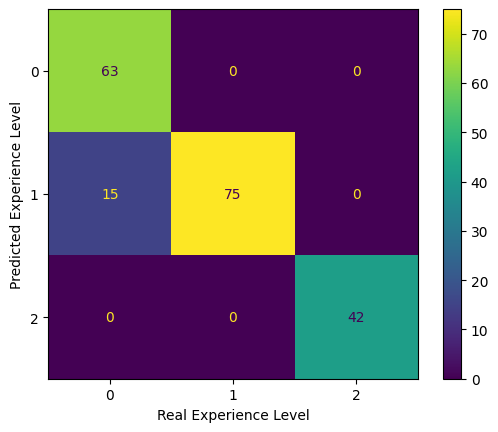

In [120]:
ConfusionMatrixDisplay(confusion_matrix(y_pred, yc_test)).plot()
plt.xlabel('Real Experience Level')
plt.ylabel('Predicted Experience Level')
plt.show()

## Neural Network

In [183]:
rd_state = 32
Xc_train,Xc_temp,yc_train,yc_temp = train_test_split(gymDum_noEL,gym['Experience_Level'].astype('int')-1,test_size=0.2,random_state=rd_state)
Xc_val, Xc_test, yc_val, yc_test = train_test_split(Xc_temp, yc_temp, test_size=0.5,random_state=rd_state)

In [186]:

def lr_schedule(epoch, lr):
    if epoch < 10:
        return lr  # Keep the learning rate constant for the first 10 epochs
    else:
        return lr * 0.9  # Decay by 10% after 10 epochs

lr_scheduler = LearningRateScheduler(lr_schedule)

keras_model = Sequential()
keras_model.add(Input(shape=(X_train.shape[1],)))
keras_model.add(Dense(128,activation="relu",kernel_initializer='he_normal'))
keras_model.add(BatchNormalization())  
# keras_model.add(Dropout(0.3))
keras_model.add(Dense(64,activation="relu",kernel_initializer='he_normal'))
keras_model.add(BatchNormalization())  
# keras_model.add(Dropout(0.3))
keras_model.add(Dense(32,activation="relu",kernel_initializer='he_normal'))
keras_model.add(BatchNormalization())  

keras_model.add(Dense(32,activation="relu",kernel_initializer='he_normal'))
keras_model.add(BatchNormalization())  

keras_model.add(Dense(16,activation="relu",kernel_initializer='he_normal'))
keras_model.add(BatchNormalization())  
# keras_model.add(Dropout(0.3))
# keras_model.add(Dense(5,activation="relu"))
keras_model.add(Dense(3,activation="softmax"))


keras_model.compile(optimizer=Nadam(learning_rate=0.4),
                   loss='sparse_categorical_crossentropy',
                   metrics=["accuracy"])

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,         # number of epochs with no improvement
    mode='min',
    verbose=1,
    restore_best_weights=True  # restores weights from best epoch
)
history = keras_model.fit(Xc_train,yc_train,
                         epochs=200,batch_size=32,
                          callbacks=[early_stop,lr_scheduler],
                         validation_data=(Xc_val,yc_val))

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.4811 - loss: 1.4579 - val_accuracy: 0.1753 - val_loss: 1622.7889 - learning_rate: 0.4000
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6840 - loss: 0.6794 - val_accuracy: 0.4021 - val_loss: 40.6717 - learning_rate: 0.4000
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7309 - loss: 0.5253 - val_accuracy: 0.2165 - val_loss: 149.8460 - learning_rate: 0.4000
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6914 - loss: 0.5846 - val_accuracy: 0.4021 - val_loss: 11.1700 - learning_rate: 0.4000
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6621 - loss: 0.7028 - val_accuracy: 0.3196 - val_loss: 11.5615 - learning_rate: 0.4000
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7413 - loss: 0.5099 - val_accuracy: 0.3299 - val_loss: 13.0488 - learning_rate: 0.4000
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7207 - loss: 0.5405

In [185]:
loss, accuracy = keras_model.evaluate(Xc_test, yc_test, verbose=1)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8874 - loss: 0.2297 
Test Accuracy: 88.78%


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
1


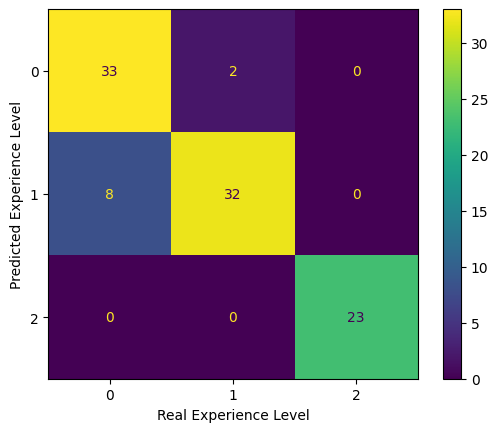

In [181]:
yc_pred = np.argmax(keras_model.predict(Xc_test),axis=1)
print(yc_pred[0])
ConfusionMatrixDisplay(confusion_matrix(yc_pred, yc_test)).plot()
plt.xlabel('Real Experience Level')
plt.ylabel('Predicted Experience Level')
plt.show()

# Biais Detection